# Premier League 2025/26 — Exploratory Data Analysis

**Dataset:** `fusion_dataset.csv` · **319 partidos** · **41 features** · Temporada agosto 2025 – abril 2026

---

Este notebook analiza el dataset construido para predecir el resultado de partidos de la Premier League (victoria local **H**, empate **D**, victoria visitante **A**).

El dataset no contiene el marcador final del partido — es un conjunto de **features pre-partido** que captura información disponible *antes de que el balón ruede*: el historial y forma de cada equipo, diferencias de calidad entre plantillas, métricas avanzadas (xG, PPDA) y las cuotas del mercado de apuestas. El objetivo del EDA es entender la estructura de estos datos, detectar patrones y verificar que el dataset sea apto para entrenar un modelo de clasificación multiclase.

**Librerías:** pandas · matplotlib · seaborn · plotly

## 0. Configuración

In [1]:
import subprocess, sys, math
for pkg in ['pandas', 'matplotlib', 'seaborn', 'plotly', 'nbformat']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencias listas.')

Dependencias listas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

# Colores oficiales de la Premier League
PL_PURPLE = '#38003c'
PL_GREEN  = '#00ff85'
PL_PINK   = '#e90052'
PALETTE   = {'H': PL_GREEN, 'D': '#888888', 'A': PL_PINK}
LABELS    = {'H': 'Local gana (H)', 'D': 'Empate (D)', 'A': 'Visitante gana (A)'}

DATA_PATH = '../data/processed/fusion_dataset.csv'

# ── Helper: histogramas por grupo de variables coloreados por resultado ──────
def plot_group(df, cols, group_title, ncols=3):
    """Muestra histogramas de densidad superpuestos por clase de resultado."""
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
    axes_flat = np.array(axes).flatten()

    for i, col in enumerate(cols):
        ax = axes_flat[i]
        for result in ['H', 'D', 'A']:
            data = df[df['Target_FTR'] == result][col].dropna()
            ax.hist(data, bins=22, alpha=0.45, color=PALETTE[result],
                    label=LABELS[result], density=True, edgecolor='white')
            ax.axvline(data.median(), color=PALETTE[result],
                       linewidth=1.8, linestyle='--', alpha=0.9)
        ax.set_title(col, fontsize=9, pad=5)
        ax.set_ylabel('Densidad', fontsize=8)
        ax.tick_params(labelsize=8)
        if i == 0:
            ax.legend(fontsize=8, framealpha=0.75)

    for j in range(len(cols), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(group_title, fontsize=13, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Configuración lista.')

Configuración lista.


---
## 1. Carga y vista previa

El dataset es el resultado de un proceso de construcción de features que combina tres fuentes principales: resultados históricos de la Premier League, métricas avanzadas de rendimiento (Understat) y valoraciones de mercado (Transfermarkt). Cada fila representa un partido; las columnas describen el estado de ambos equipos *antes* de que se dispute.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Jornada aproximada: 10 partidos por jornada en la Premier League
df['Matchweek'] = (df.index // 10) + 1

print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
print(f'Rango de fechas: {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Equipos: {df["HomeTeam"].nunique()}')
df.head(10)

Filas: 319  |  Columnas: 42
Rango de fechas: 2025-08-15  →  2026-04-13
Equipos: 20


,Date,HomeTeam,AwayTeam,Target_FTR,Elo_Diff,Home_SquadValue,Away_SquadValue,B365H,B365D,B365A,...,A_PPDA_Avg_Tot,A_DeepComp_Avg_Tot,A_GD_Avg_Tot,A_Points_L5,A_Goals_Scored_L5,A_Goals_Against_L5,A_Points_Abs_Tot,A_GD_Abs_Tot,H_xG_GD_Avg_Tot,Matchweek
0,2025-08-15,Liverpool,Bournemouth,H,185.329834,1020,507,1.30,6.00,8.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2025-08-16,Aston Villa,Newcastle United,D,4.278687,548,708,2.25,3.50,2.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2025-08-16,Brighton,Fulham,D,45.409546,494,387,1.91,3.60,4.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2025-08-16,Sunderland,West Ham,H,-203.022705,382,363,3.25,3.40,2.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2025-08-16,Tottenham,Burnley,H,44.418457,803,253,1.38,4.75,8.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,2025-08-16,Wolverhampton Wanderers,Manchester City,A,-224.179199,277,1310,6.25,4.75,1.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
6,2025-08-17,Nottingham Forest,Brentford,H,-8.445679,568,470,2.20,3.30,3.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7,2025-08-17,Chelsea,Crystal Palace,D,67.769043,1160,541,1.62,4.33,4.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
8,2025-08-17,Manchester United,Arsenal,A,-193.855469,747,1230,3.60,3.60,1.95,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9,2025-08-18,Leeds,Everton,H,-71.633789,346,450,2.38,3.30,3.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


---
## 2. Información general

Antes de cualquier análisis se revisan tres aspectos básicos de calidad: la dimensión del dataset, los tipos de dato de cada columna y la presencia de valores faltantes. Esto permite identificar si hay columnas mal tipadas, detectar vacíos que puedan afectar el entrenamiento y confirmar que el dataset está en el formato esperado.

In [4]:
print('── TIPOS DE DATO ──')
print(df.dtypes.value_counts().rename_axis('dtype').reset_index(name='columnas').to_string(index=False))

print('\n── VALORES NULOS ──')
null_df = df.isnull().sum().reset_index()
null_df.columns = ['Columna', 'Nulos']
null_df['% del total'] = (null_df['Nulos'] / len(df) * 100).round(2)
print(null_df[null_df['Nulos'] > 0].to_string(index=False))

── TIPOS DE DATO ──
         dtype  columnas
       float64        33
         int64         5
        object         3
datetime64[ns]         1

── VALORES NULOS ──
                Columna  Nulos  % del total
       H_Points_Avg_Tot     10         3.13
           H_xG_Avg_Tot     10         3.13
         H_npxG_Avg_Tot     10         3.13
 H_Goals_Scored_Avg_Tot     10         3.13
H_Goals_Against_Avg_Tot     10         3.13
         H_xPts_Avg_Tot     10         3.13
         H_PPDA_Avg_Tot     10         3.13
     H_DeepComp_Avg_Tot     10         3.13
           H_GD_Avg_Tot     10         3.13
            H_Points_L5     10         3.13
      H_Goals_Scored_L5     10         3.13
     H_Goals_Against_L5     10         3.13
       H_Points_Abs_Tot     10         3.13
           H_GD_Abs_Tot     10         3.13
       A_Points_Avg_Tot     10         3.13
           A_xG_Avg_Tot     10         3.13
         A_npxG_Avg_Tot     10         3.13
 A_Goals_Scored_Avg_Tot     10         3.1

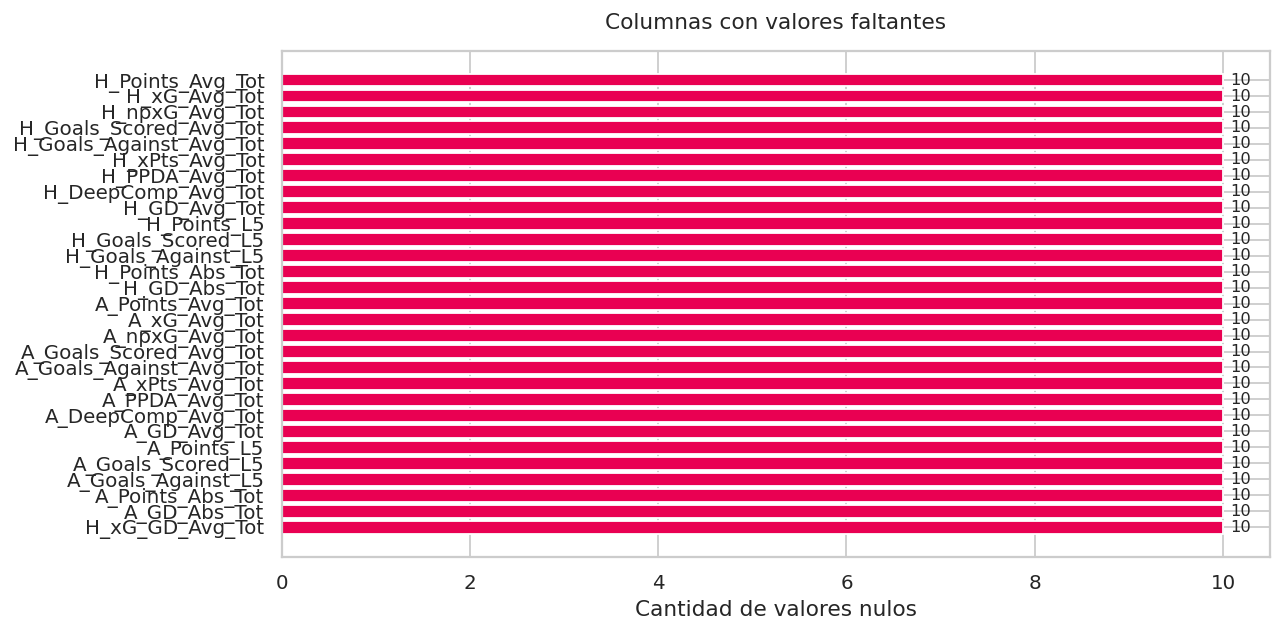

Todos los nulos pertenecen a la jornada 1 de la temporada (primeros 10 partidos).
En esa fecha no existe historial acumulado previo, por lo que las métricas de
rendimiento no pueden calcularse. El patrón es estructural, no un error de datos.


In [5]:
# Visualización del patrón de nulos
null_counts = df.isnull().sum()
null_cols   = null_counts[null_counts > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(null_cols.index, null_cols.values, color=PL_PINK, edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Cantidad de valores nulos')
ax.set_title('Columnas con valores faltantes', pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    'Todos los nulos pertenecen a la jornada 1 de la temporada (primeros 10 partidos).\n'
    'En esa fecha no existe historial acumulado previo, por lo que las métricas de\n'
    'rendimiento no pueden calcularse. El patrón es estructural, no un error de datos.'
)

---
## 3. Estadísticas descriptivas

La tabla descriptiva da una primera impresión de la escala, el rango y la dispersión de cada variable numérica. El **coeficiente de variación (CV%)** complementa la desviación estándar normalizándola respecto a la media, lo que permite comparar la variabilidad entre variables con escalas muy distintas (por ejemplo, puntos vs. valor de mercado en millones).

In [6]:
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c != 'Matchweek']

desc = df[numeric_cols].describe().T
desc['cv%'] = (desc['std'] / desc['mean'].abs() * 100).round(1)

desc.style \
    .background_gradient(cmap='Blues',   subset=['mean']) \
    .background_gradient(cmap='Oranges', subset=['std']) \
    .background_gradient(cmap='Reds',    subset=['cv%']) \
    .format(precision=3)

,count,mean,std,min,25%,50%,75%,max,cv%
Elo_Diff,319.000,-0.478,142.460,-403.600,-106.756,-4.734,103.697,388.479,29788.300
Home_SquadValue,319.000,626.063,311.236,253.000,384.500,507.000,747.000,1310.000,49.700
Away_SquadValue,319.000,628.473,313.544,253.000,384.500,507.000,775.000,1310.000,49.900
B365H,319.000,2.635,1.380,1.130,1.670,2.200,3.250,11.000,52.400
B365D,319.000,3.976,0.817,3.000,3.500,3.750,4.200,8.500,20.500
B365A,319.000,3.936,2.521,1.270,2.200,3.300,4.750,21.000,64.000
H2H_Overall_L5,319.000,-0.376,6.930,-15.000,-6.000,0.000,4.500,15.000,1842.300
H2H_Venue_L5,319.000,1.401,6.409,-15.000,-3.000,0.000,6.000,15.000,457.400
H_Points_Avg_Tot,309.000,1.350,0.556,0.000,1.000,1.385,1.667,3.000,41.200
H_xG_Avg_Tot,309.000,1.432,0.398,0.446,1.105,1.418,1.769,2.659,27.800


---
## 4. Distribución de variables

En cada gráfico se superponen las distribuciones de las tres clases de resultado (**verde = victoria local**, **gris = empate**, **rosa = victoria visitante**) y se marca la mediana de cada clase con una línea discontinua del mismo color.

Esto permite responder la pregunta clave de un EDA orientado a ML: **¿esta variable separa las tres clases o sus distribuciones son prácticamente idénticas?** Si los histogramas de las tres clases son indistinguibles, la variable aporta poco poder predictivo por sí sola. Si las medianas de cada clase están claramente separadas, la variable es informativa para el modelo.

### 4.1 Variable objetivo — `Target_FTR`

`Target_FTR` (Full Time Result) es la variable que el modelo deberá predecir. Conocer su distribución es esencial: un desbalance pronunciado entre clases puede sesgar al modelo hacia la clase mayoritaria y requerir técnicas de balanceo durante el entrenamiento.

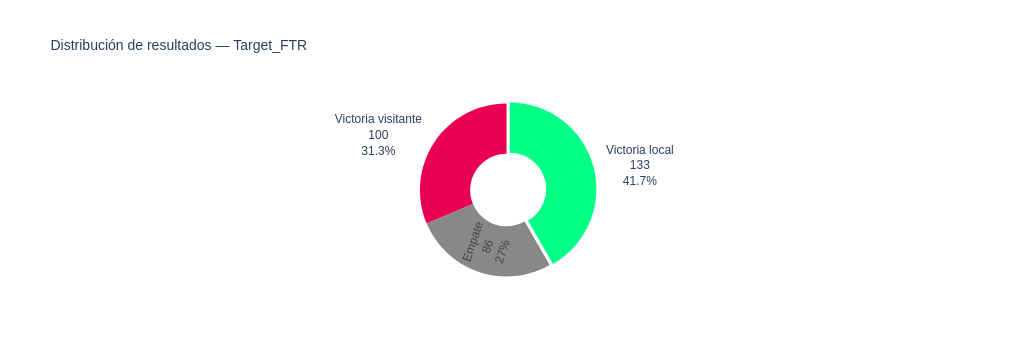

Distribución de clases:
  Victoria local        : 133 partidos  (41.7%)
  Victoria visitante    : 100 partidos  (31.3%)
  Empate                :  86 partidos  (27.0%)


In [7]:
result_map   = {'H': 'Victoria local', 'D': 'Empate', 'A': 'Victoria visitante'}
result_counts = df['Target_FTR'].map(result_map).value_counts()

fig = px.pie(
    values=result_counts.values,
    names=result_counts.index,
    title='Distribución de resultados — Target_FTR',
    color_discrete_sequence=[PL_GREEN, PL_PINK, '#888'],
    hole=0.42
)
fig.update_traces(textinfo='percent+label+value', pull=[0.04, 0, 0])
fig.update_layout(showlegend=False, title_font_size=14)
fig.show()

print('Distribución de clases:')
for k, v in df['Target_FTR'].value_counts().items():
    print(f'  {result_map[k]:<22}: {v:>3} partidos  ({v/len(df)*100:.1f}%)')

El dataset presenta un **desbalance moderado**: las victorias locales son la clase más frecuente (41.7%), lo que refleja la conocida ventaja de jugar en casa en el fútbol. Los empates son la clase minoritaria (27%), y también la más difícil de predecir al carecer de una señal fuerte. Este desequilibrio es real y esperado, no un artefacto del dataset.

### 4.2 Variables de contexto del partido

Este grupo captura la diferencia de calidad entre los dos equipos antes de que empiece el partido:

| Variable | Qué mide |
|---|---|
| `Elo_Diff` | Diferencia de rating Elo (local − visitante). Valores positivos indican que el local es más fuerte |
| `Home_SquadValue` | Valor de mercado de la plantilla local (M€) |
| `Away_SquadValue` | Valor de mercado de la plantilla visitante (M€) |
| `H2H_Overall_L5` | Puntos del local en los últimos 5 enfrentamientos directos (cualquier campo) |
| `H2H_Venue_L5` | Puntos del local en los últimos 5 encuentros jugados en ese estadio específico |

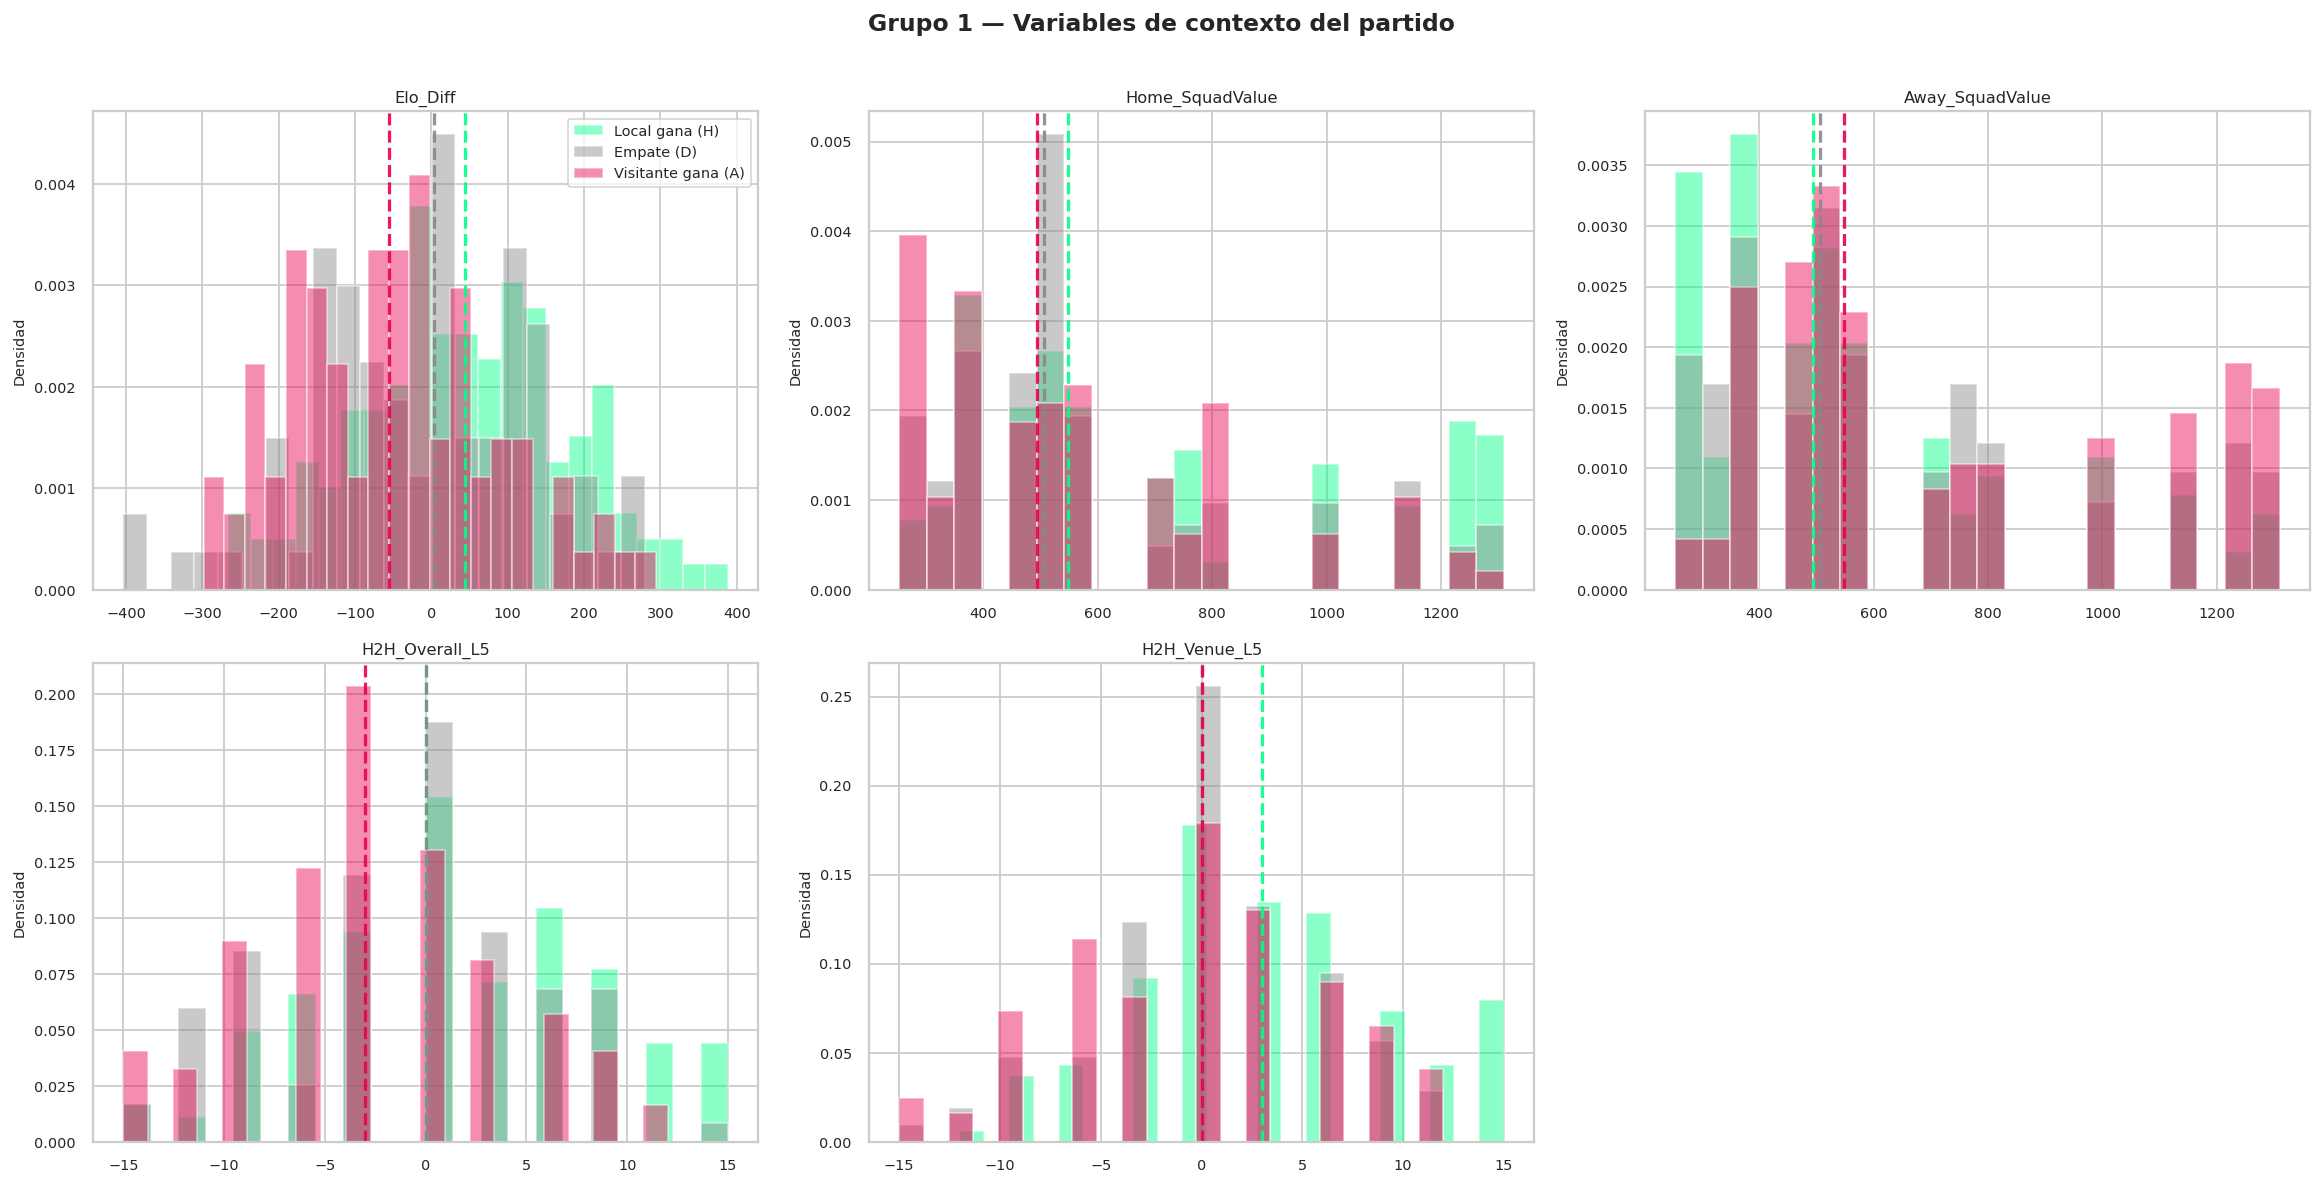

In [8]:
group_context = ['Elo_Diff', 'Home_SquadValue', 'Away_SquadValue', 'H2H_Overall_L5', 'H2H_Venue_L5']
plot_group(df, group_context, 'Grupo 1 — Variables de contexto del partido', ncols=3)

**Lectura:** `Elo_Diff` es la variable con mayor separación entre clases de todo el dataset. Cuando el local tiene un Elo superior (valores positivos), la clase verde (H) claramente domina. El valor de mercado de las plantillas también muestra algo de separación, aunque es menos nítido.

### 4.3 Cuotas de apuestas — Bet365

Las cuotas de Bet365 (`B365H`, `B365D`, `B365A`) reflejan la **probabilidad implícita** que el mercado asigna a cada resultado. Una cuota baja significa que el mercado considera ese resultado muy probable. Estas variables funcionan como un *meta-modelo* externo: agregan toda la información pública disponible (incluyendo información que quizás el propio dataset no captura) en un solo número.

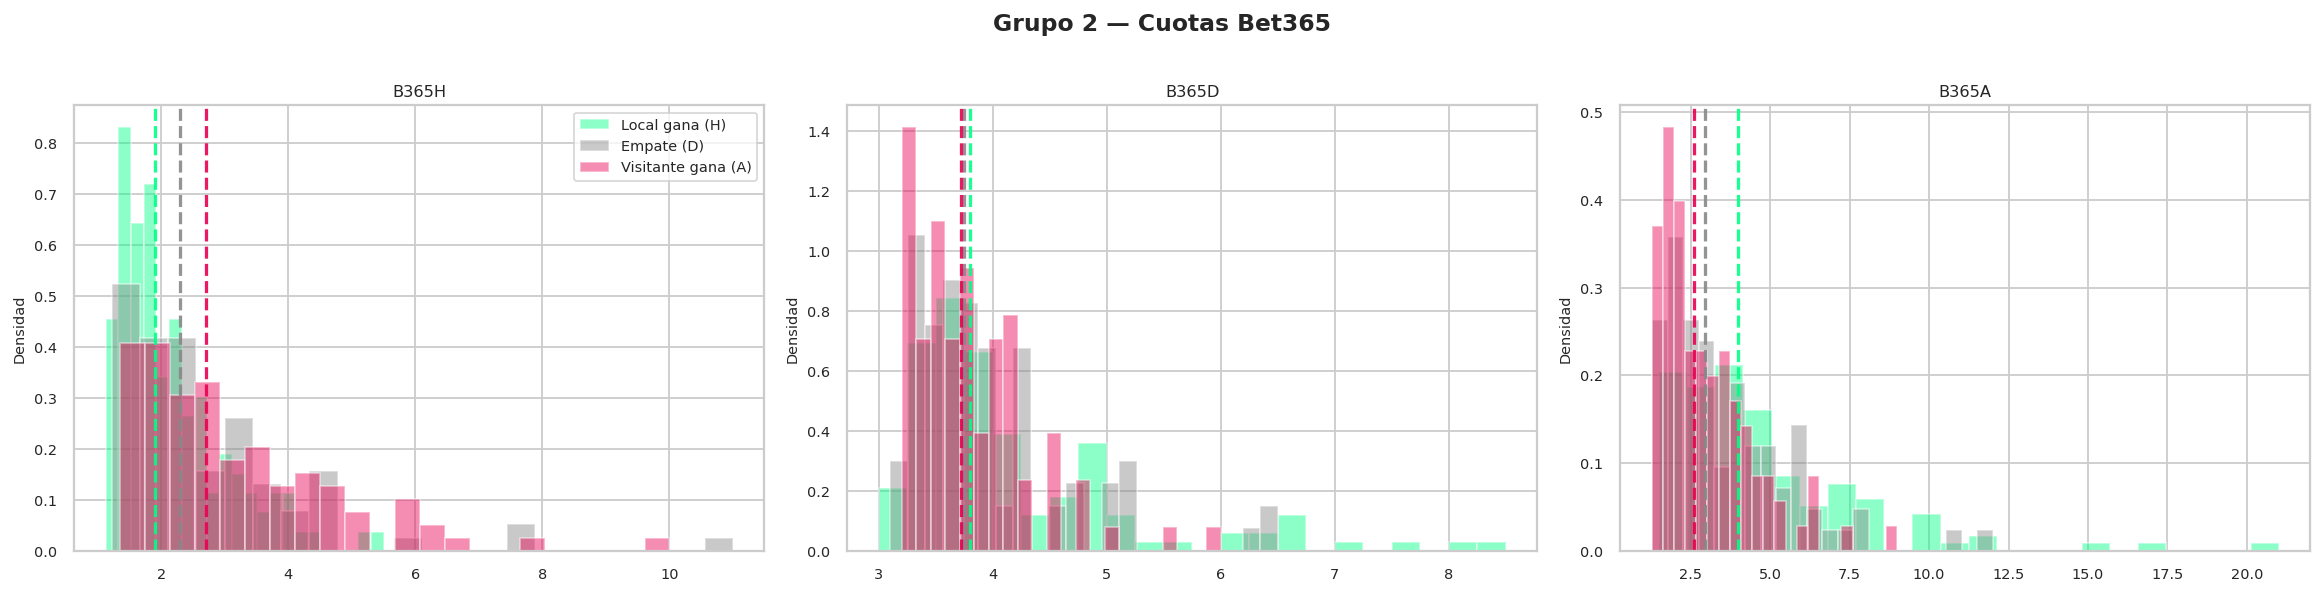

In [9]:
group_odds = ['B365H', 'B365D', 'B365A']
plot_group(df, group_odds, 'Grupo 2 — Cuotas Bet365', ncols=3)

**Lectura:** La cuota de victoria local (`B365H`) separa bien las clases: cuando la cuota es baja (local muy favorito), la clase H domina. Lo mismo aplica simétricamente para `B365A`. La cuota de empate (`B365D`) tiene la separación menos clara de las tres, consistente con que los empates son el resultado más difícil de anticipar.

### 4.4 Rendimiento acumulado en la temporada — Equipo local

Este grupo recoge métricas calculadas sobre **todos los partidos disputados hasta la fecha** por el equipo local. Son promedios por partido (`_Avg_Tot`) y totales acumulados (`_Abs_Tot`), lo que captura el nivel de forma general de la temporada:

| Variable | Qué mide |
|---|---|
| `H_Points_Avg_Tot` | Puntos por partido (acumulado temporada) |
| `H_xG_Avg_Tot` | Expected Goals por partido — calidad de las ocasiones creadas |
| `H_npxG_Avg_Tot` | xG sin penaltis — versión más limpia del xG |
| `H_Goals_Scored_Avg_Tot` | Goles anotados por partido |
| `H_Goals_Against_Avg_Tot` | Goles recibidos por partido |
| `H_xPts_Avg_Tot` | Puntos esperados basados en xG |
| `H_PPDA_Avg_Tot` | Passes Allowed Per Defensive Action — métrica de presión (menor = más presión) |
| `H_DeepComp_Avg_Tot` | Pases completados en zonas profundas del campo rival |
| `H_GD_Avg_Tot` | Diferencia de goles por partido |
| `H_Points_Abs_Tot` | Puntos totales acumulados en la temporada |
| `H_GD_Abs_Tot` | Diferencia de goles acumulada |
| `H_xG_GD_Avg_Tot` | Diferencial xG (xG propio − xG rival) |

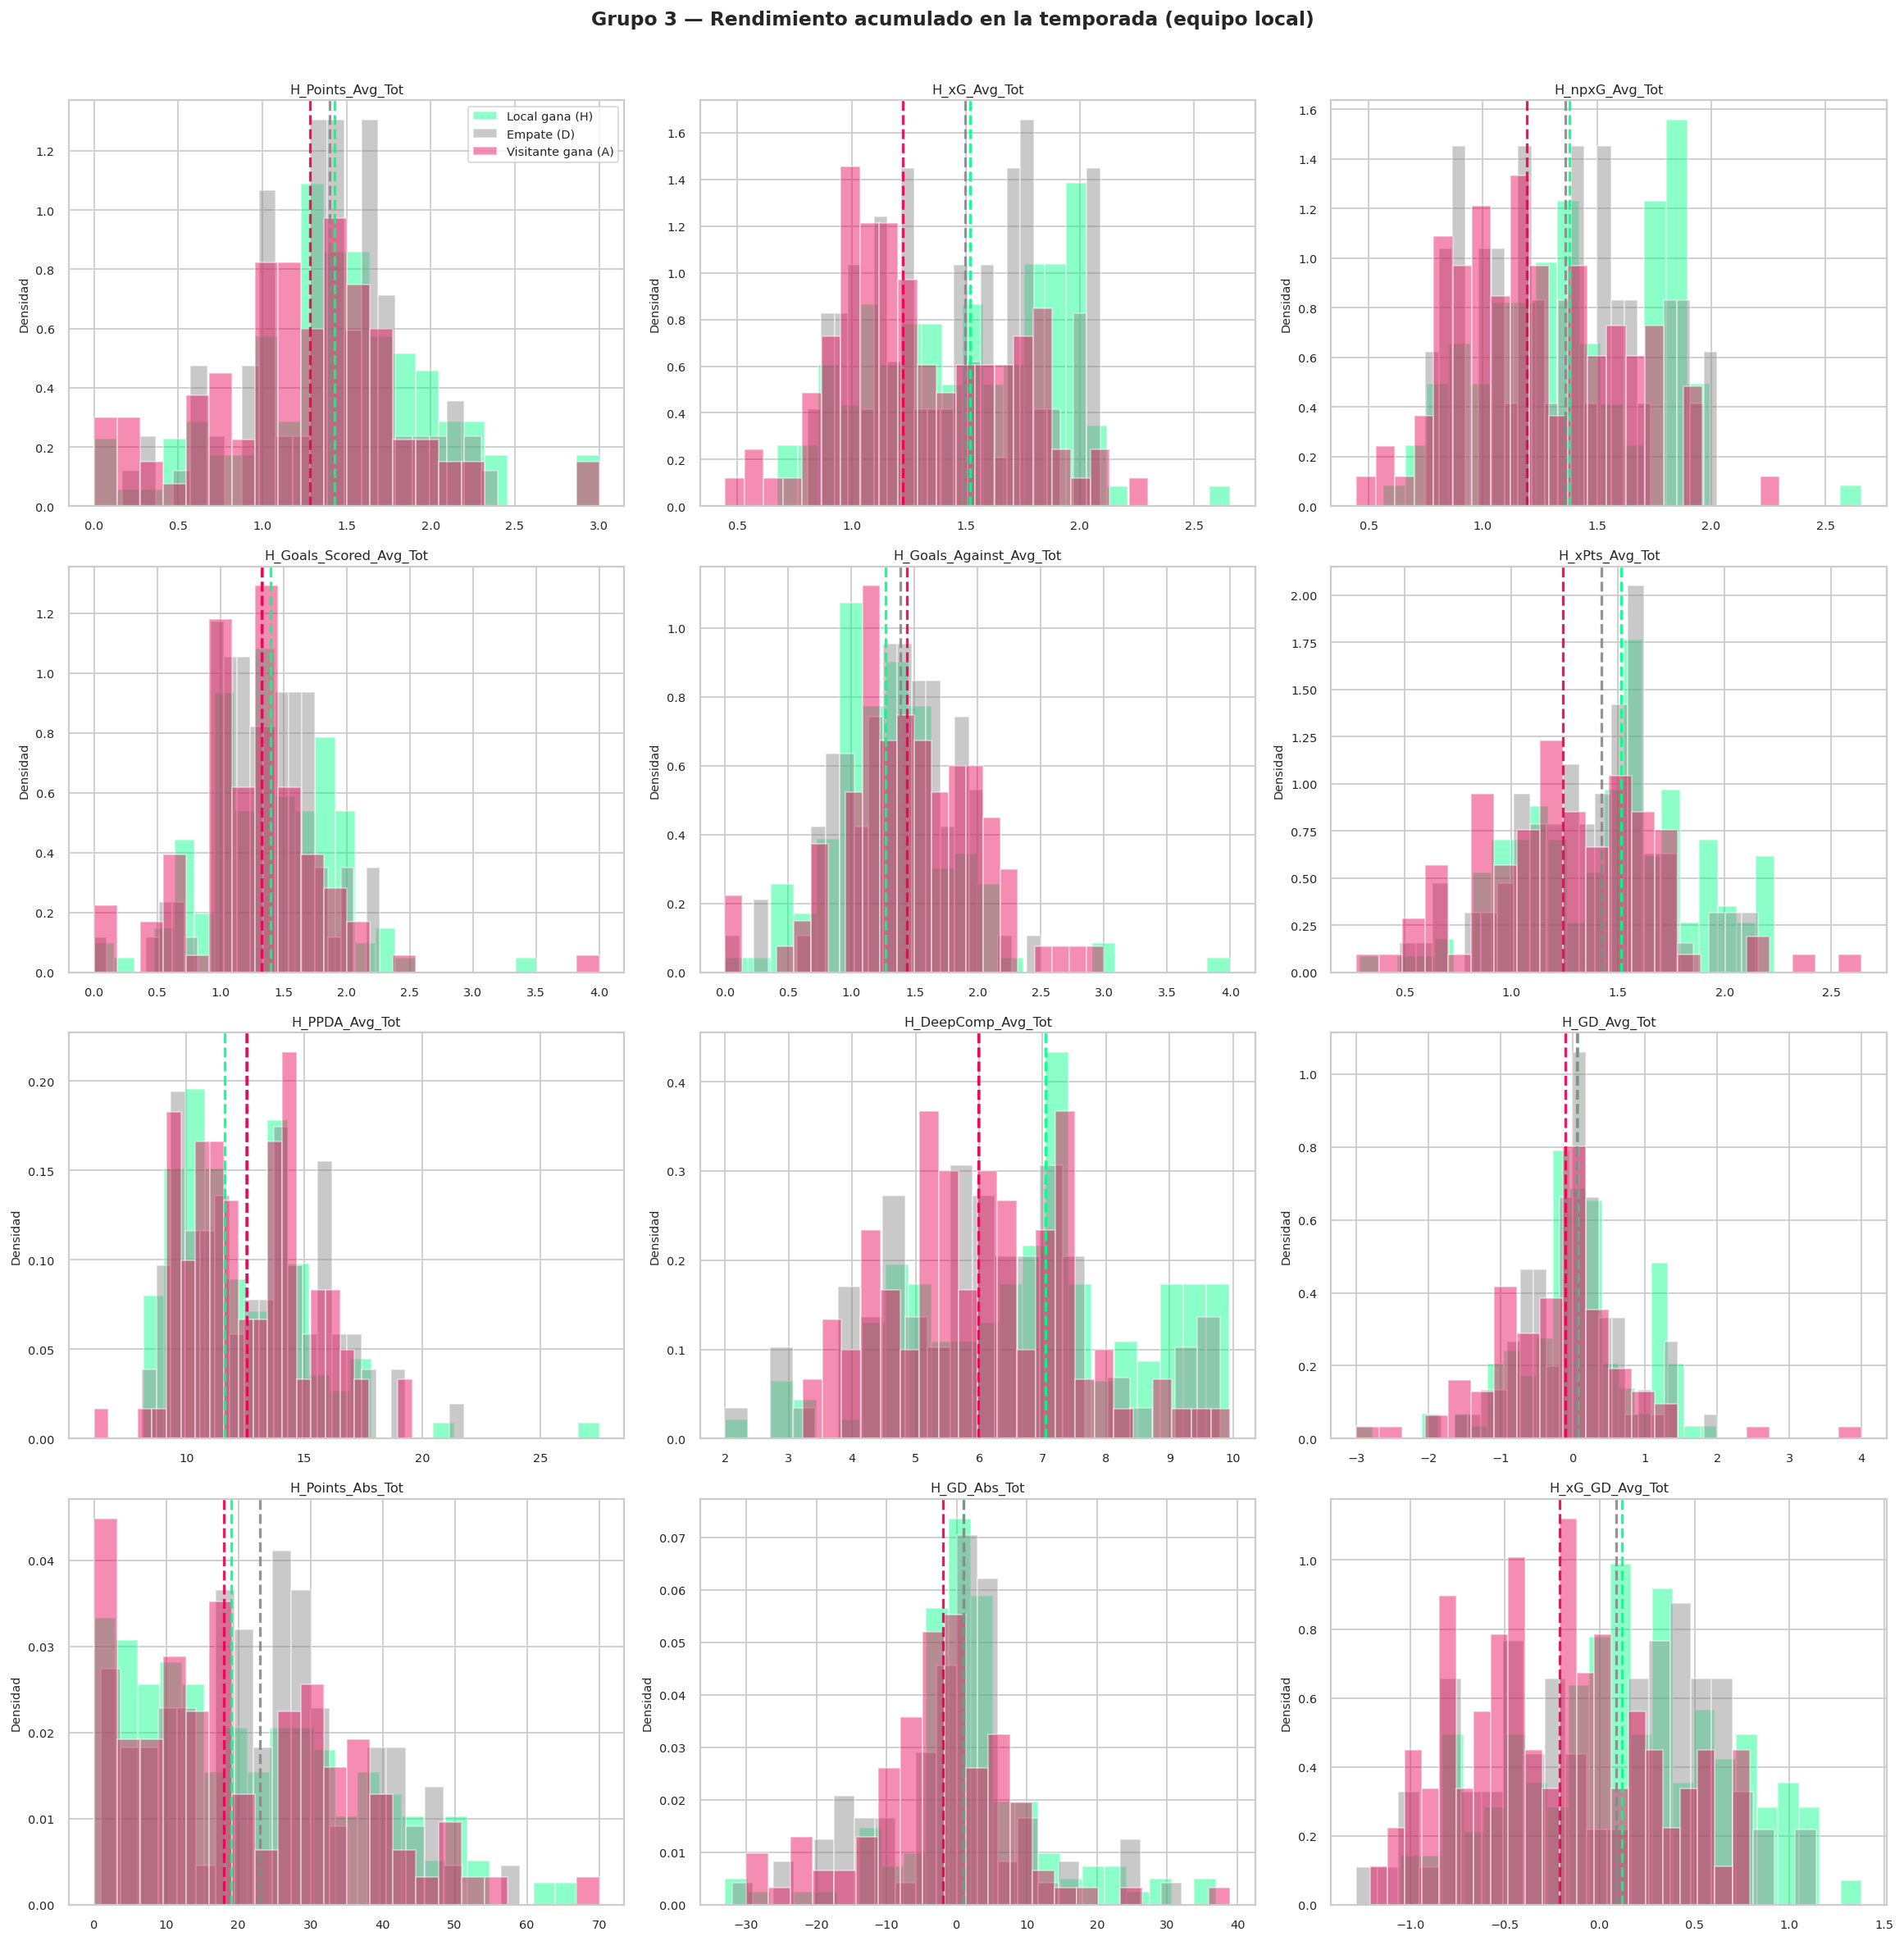

In [10]:
group_home_acc = [
    'H_Points_Avg_Tot', 'H_xG_Avg_Tot', 'H_npxG_Avg_Tot',
    'H_Goals_Scored_Avg_Tot', 'H_Goals_Against_Avg_Tot', 'H_xPts_Avg_Tot',
    'H_PPDA_Avg_Tot', 'H_DeepComp_Avg_Tot', 'H_GD_Avg_Tot',
    'H_Points_Abs_Tot', 'H_GD_Abs_Tot', 'H_xG_GD_Avg_Tot'
]
plot_group(df, group_home_acc, 'Grupo 3 — Rendimiento acumulado en la temporada (equipo local)', ncols=3)

**Lectura:** Las métricas ofensivas del local (`H_xG_Avg_Tot`, `H_Goals_Scored_Avg_Tot`, `H_Points_Avg_Tot`) muestran separación entre clases: cuando el equipo local llega con buen promedio de xG y puntos, la clase H desplaza su distribución a la derecha. `H_PPDA_Avg_Tot` presenta la distribución inversa — valores más bajos indican mayor presión, asociada también con más victorias locales.

### 4.5 Forma reciente — Equipo local (últimas 5 jornadas)

Las métricas acumuladas de temporada pueden ser engañosas si el equipo atravesó un mal inicio pero está en racha actualmente (o viceversa). Las variables `_L5` capturan la **forma reciente**: lo que sucedió en los últimos 5 partidos, dando más peso al estado actual del equipo.

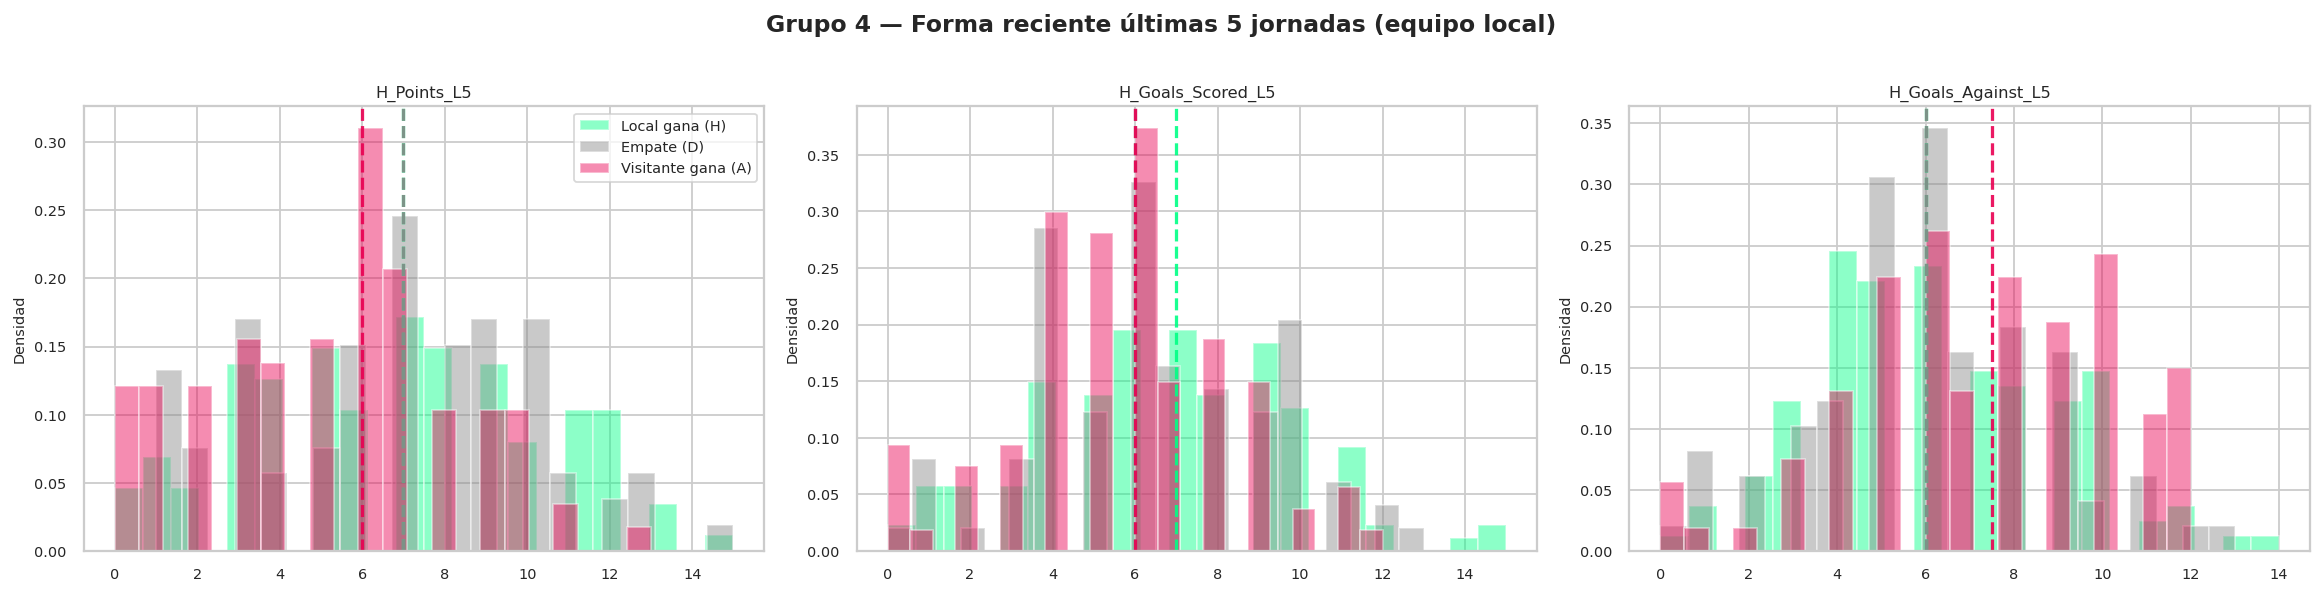

In [11]:
group_home_l5 = ['H_Points_L5', 'H_Goals_Scored_L5', 'H_Goals_Against_L5']
plot_group(df, group_home_l5, 'Grupo 4 — Forma reciente últimas 5 jornadas (equipo local)', ncols=3)

**Lectura:** `H_Points_L5` es una de las variables con separación más visible de todo el dataset — un local en racha (muchos puntos en las últimas 5 jornadas) tiene una distribución de victorias (clase H) notablemente corrida hacia la derecha. `H_Goals_Scored_L5` también separa bien, mientras que `H_Goals_Against_L5` muestra el patrón contrario esperado (menos goles recibidos → más victorias locales).

### 4.6 Rendimiento acumulado en la temporada — Equipo visitante

Mismo conjunto de métricas que el grupo 3 pero para el equipo visitante. La simetría entre grupos 3/4 y 5/6 es intencional: el modelo necesita el estado de **ambos** equipos para generar una predicción.

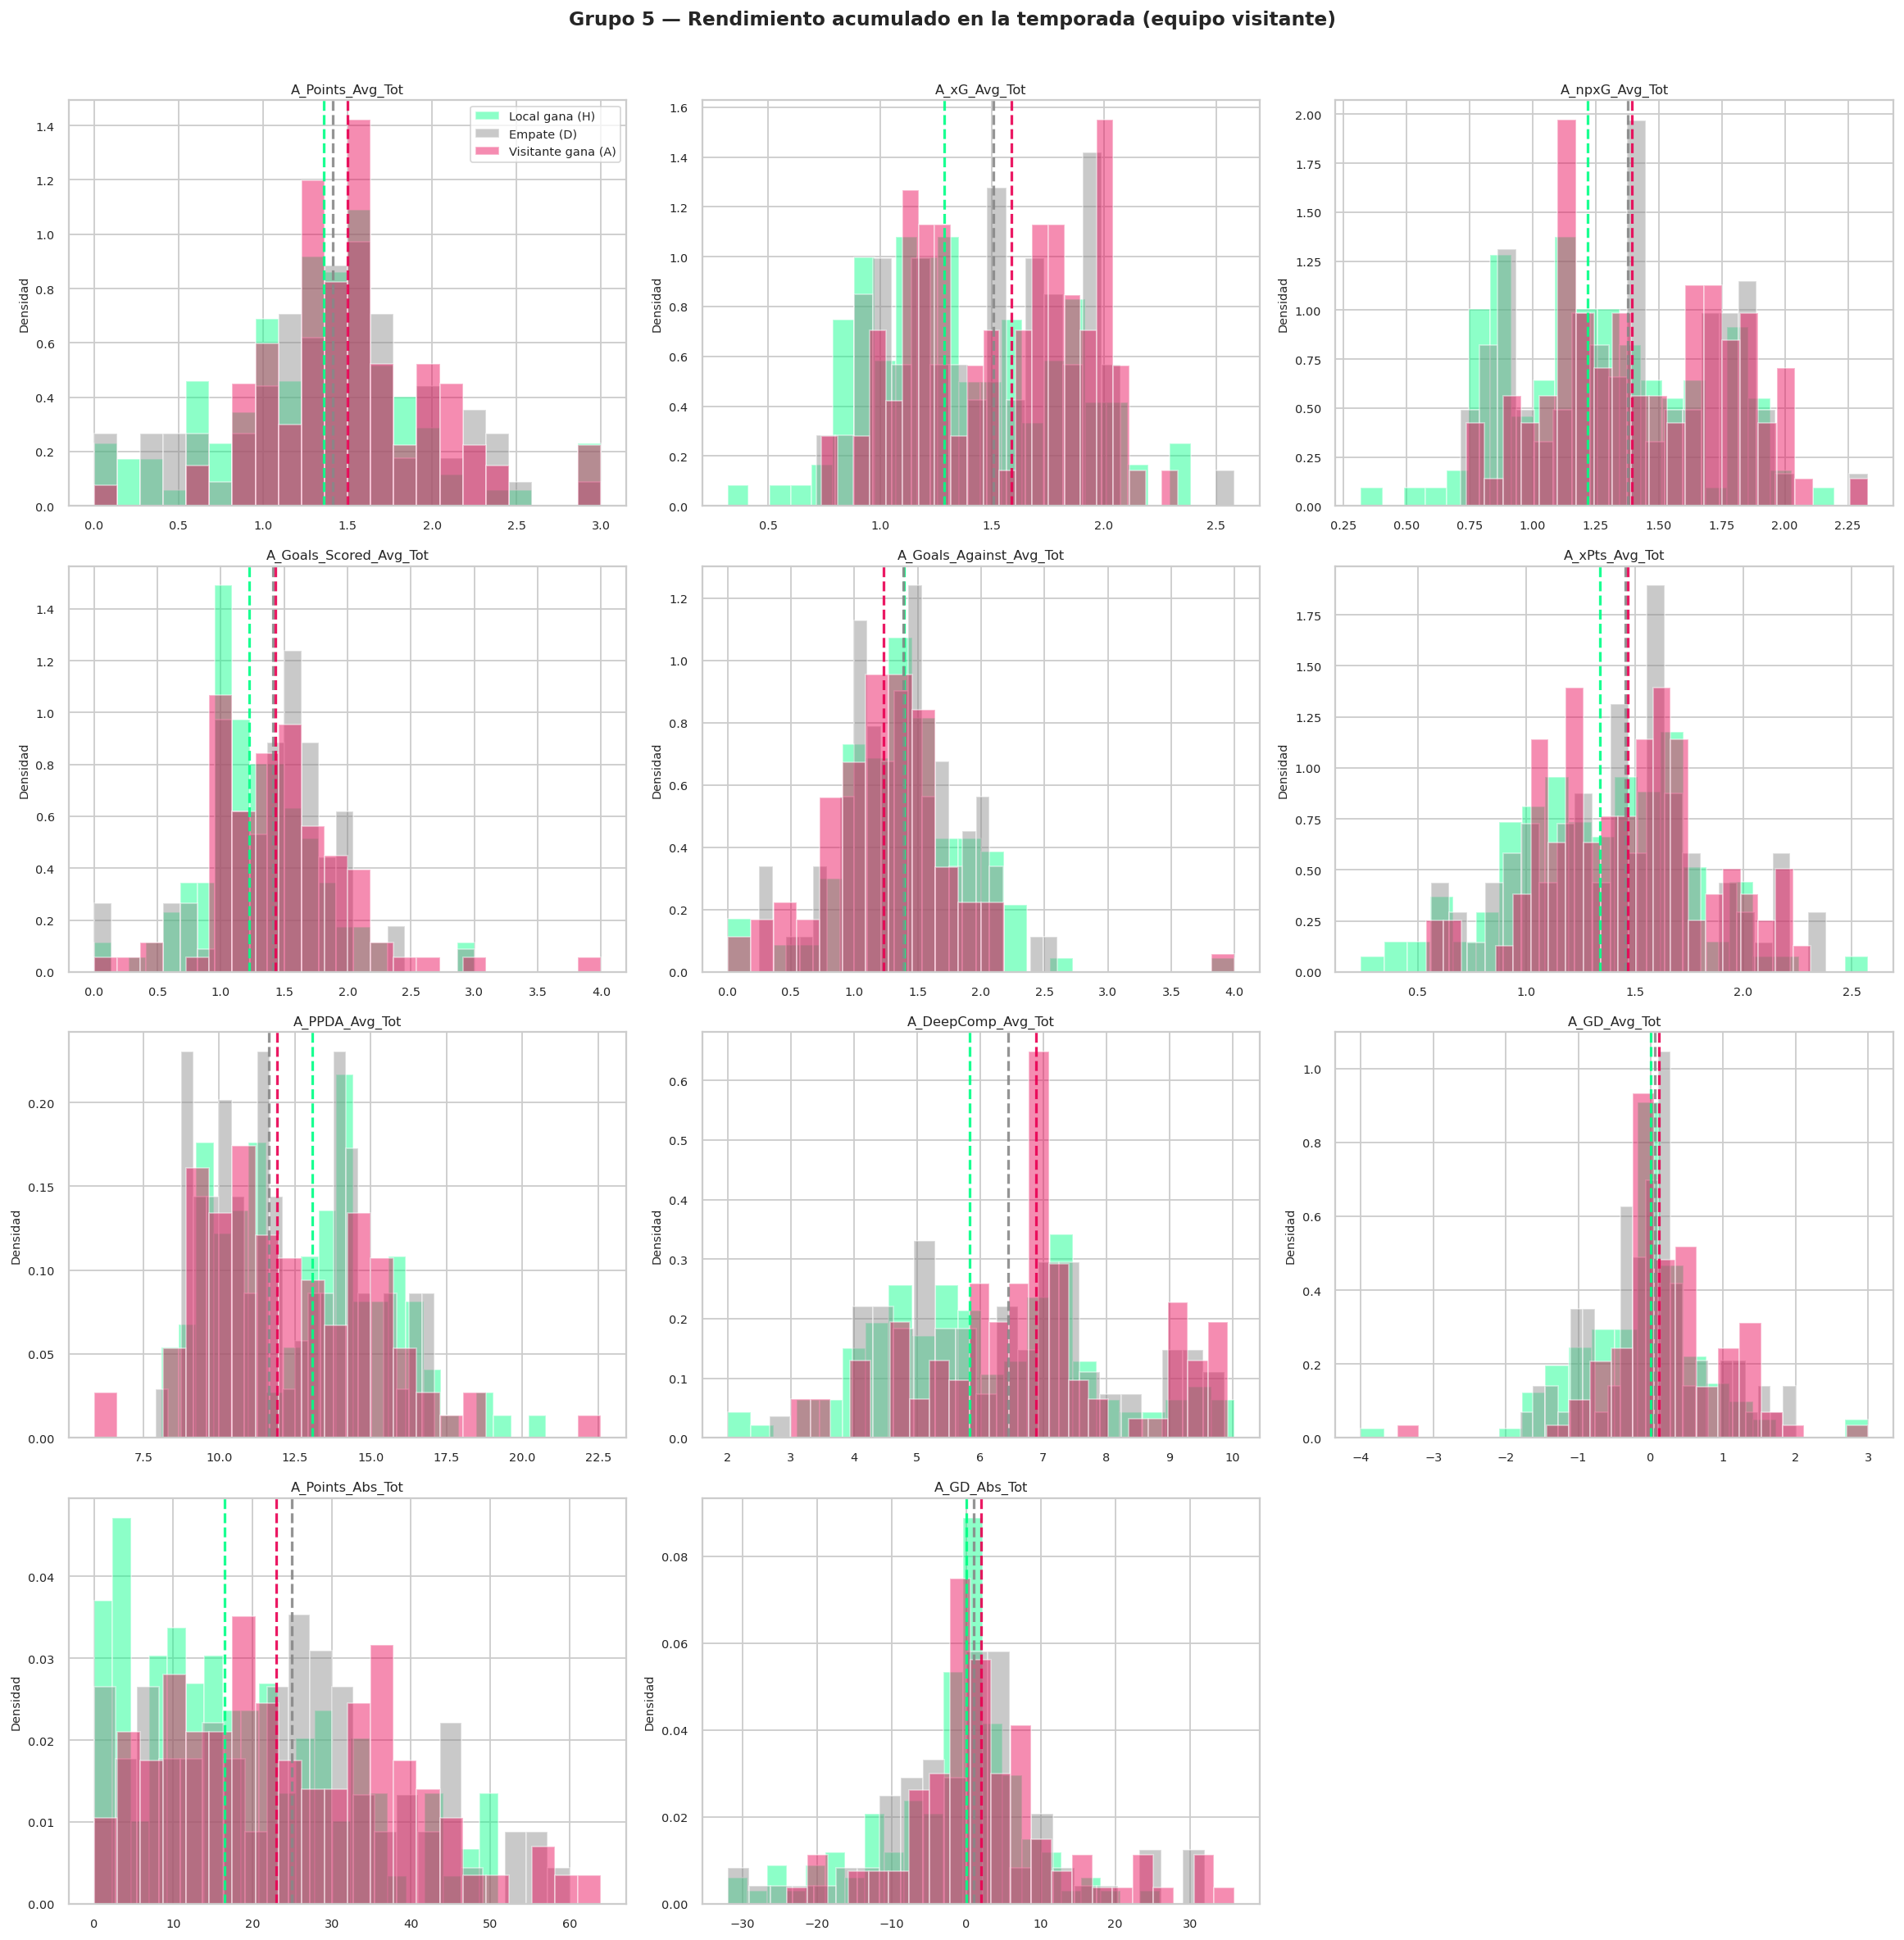

In [12]:
group_away_acc = [
    'A_Points_Avg_Tot', 'A_xG_Avg_Tot', 'A_npxG_Avg_Tot',
    'A_Goals_Scored_Avg_Tot', 'A_Goals_Against_Avg_Tot', 'A_xPts_Avg_Tot',
    'A_PPDA_Avg_Tot', 'A_DeepComp_Avg_Tot', 'A_GD_Avg_Tot',
    'A_Points_Abs_Tot', 'A_GD_Abs_Tot'
]
plot_group(df, group_away_acc, 'Grupo 5 — Rendimiento acumulado en la temporada (equipo visitante)', ncols=3)

**Lectura:** El comportamiento es simétrico al grupo del local pero en sentido contrario: cuando el visitante tiene un alto `A_xG_Avg_Tot` y `A_Points_Avg_Tot`, la clase A (victoria visitante, en rosa) es la que domina. Un visitante fuerte desplaza la probabilidad del resultado hacia su favor. La separación en las métricas del visitante es en general algo menor que la del local, consistente con la ventaja de jugar en casa.

### 4.7 Forma reciente — Equipo visitante (últimas 5 jornadas)

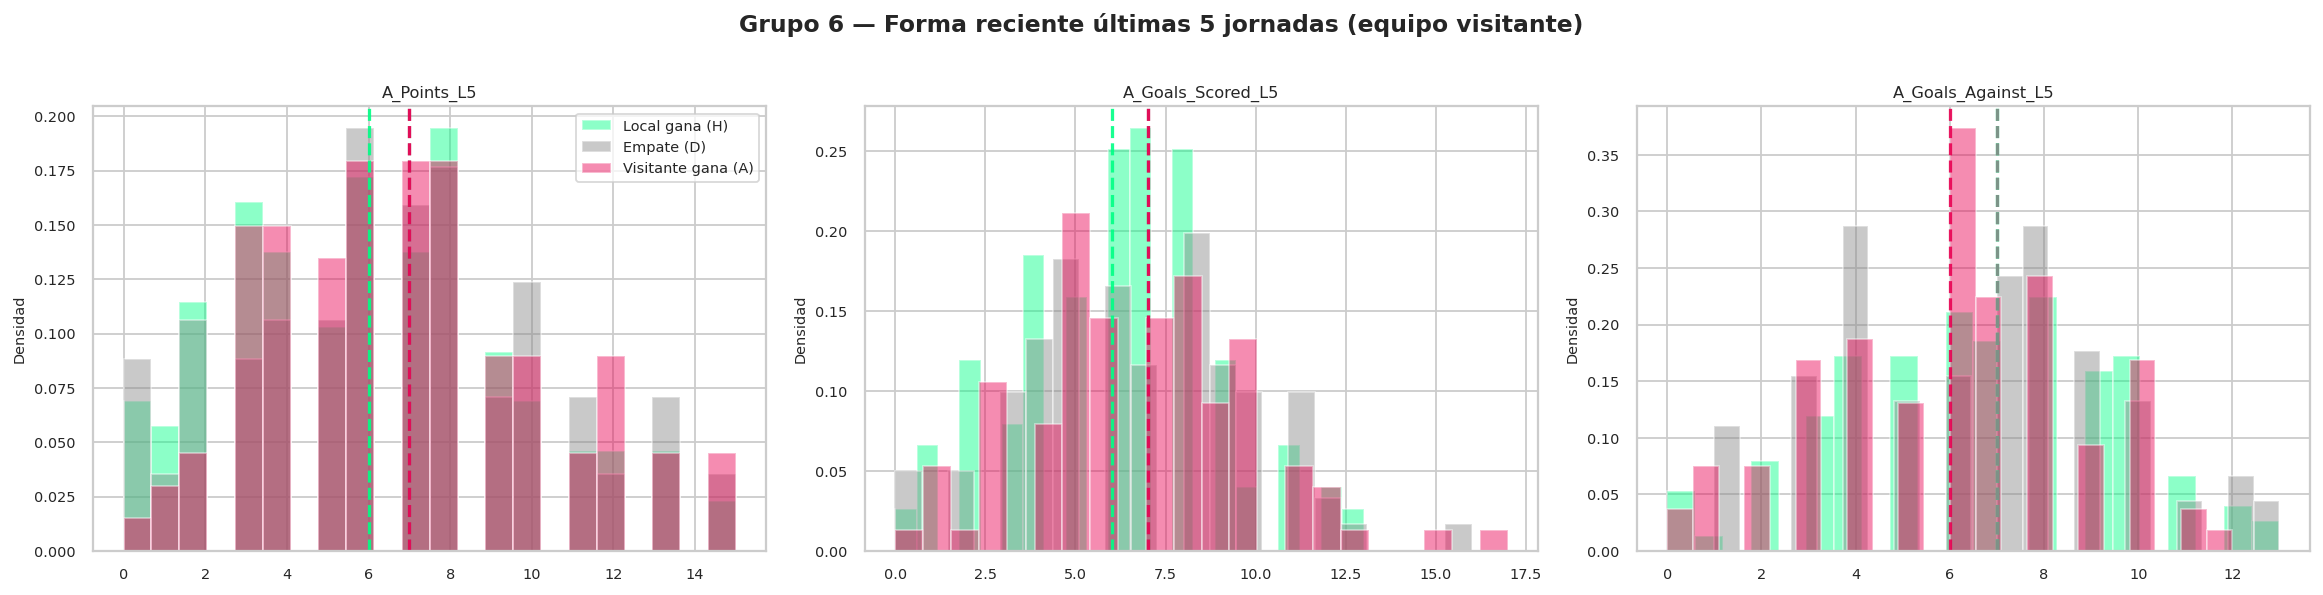

In [13]:
group_away_l5 = ['A_Points_L5', 'A_Goals_Scored_L5', 'A_Goals_Against_L5']
plot_group(df, group_away_l5, 'Grupo 6 — Forma reciente últimas 5 jornadas (equipo visitante)', ncols=3)

**Lectura:** `A_Points_L5` replica el mismo patrón que `H_Points_L5` pero desde la perspectiva visitante — un visitante en racha concentra más victorias A. Junto con `H_Points_L5`, este par de variables captura el contraste de forma reciente entre ambos equipos, que intuitivamente es uno de los factores más determinantes de un resultado.

---
## 5. Equipos: victorias, derrotas y empates

A partir de `Target_FTR`, `HomeTeam` y `AwayTeam` se reconstruye el historial de resultados de cada equipo en el dataset. Esto permite verificar que la distribución de equipos sea coherente con la clasificación real de la Premier League y detectar si algún equipo está sobrerepresentado.

In [14]:
records = []
for _, row in df.iterrows():
    ftr, home, away = row['Target_FTR'], row['HomeTeam'], row['AwayTeam']
    if ftr == 'H':
        records += [{'Team': home, 'W': 1, 'D': 0, 'L': 0},
                    {'Team': away, 'W': 0, 'D': 0, 'L': 1}]
    elif ftr == 'A':
        records += [{'Team': away, 'W': 1, 'D': 0, 'L': 0},
                    {'Team': home, 'W': 0, 'D': 0, 'L': 1}]
    else:
        records += [{'Team': home, 'W': 0, 'D': 1, 'L': 0},
                    {'Team': away, 'W': 0, 'D': 1, 'L': 0}]

team_stats = pd.DataFrame(records).groupby('Team').sum().reset_index()
team_stats['Pts']  = team_stats['W'] * 3 + team_stats['D']
team_stats['PJ']   = team_stats['W'] + team_stats['D'] + team_stats['L']
team_stats['Win%'] = (team_stats['W'] / team_stats['PJ'] * 100).round(1)
team_stats = team_stats.sort_values('Pts', ascending=False).reset_index(drop=True)
team_stats.index += 1
team_stats.rename(columns={'W': 'V', 'D': 'E', 'L': 'D_'}, inplace=True)
team_stats

,Team,V,E,D_,Pts,PJ,Win%
1,Arsenal,21,7,4,70,32,65.6
2,Manchester City,19,7,5,64,31,61.3
3,Aston Villa,16,7,9,55,32,50.0
4,Manchester United,15,10,7,55,32,46.9
5,Liverpool,15,7,10,52,32,46.9
6,Chelsea,13,9,10,48,32,40.6
7,Brentford,13,8,11,47,32,40.6
8,Everton,13,8,11,47,32,40.6
9,Brighton,12,10,10,46,32,37.5
10,Sunderland,12,10,10,46,32,37.5


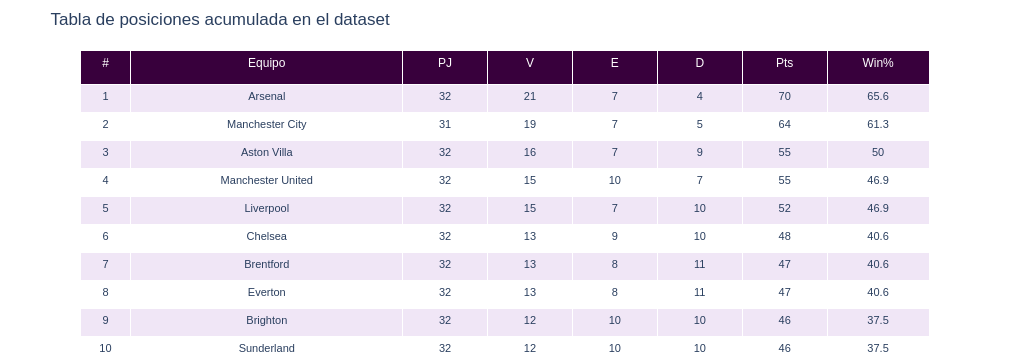

In [15]:
# Tabla estilo Premier League con plotly
ts = team_stats.reset_index().rename(columns={'index': '#'})

fig = go.Figure(data=[go.Table(
    columnwidth=[30, 160, 50, 50, 50, 50, 50, 60],
    header=dict(
        values=['#', 'Equipo', 'PJ', 'V', 'E', 'D', 'Pts', 'Win%'],
        fill_color=PL_PURPLE, font=dict(color='white', size=12),
        align='center', height=34
    ),
    cells=dict(
        values=[ts['#'], ts['Team'], ts['PJ'], ts['V'], ts['E'], ts['D_'], ts['Pts'], ts['Win%']],
        fill_color=[['#f0e6f6' if i % 2 == 0 else 'white' for i in range(len(ts))]]*8,
        align='center', height=28, font=dict(size=11)
    )
)])
fig.update_layout(title='Tabla de posiciones acumulada en el dataset', margin=dict(t=50, b=0))
fig.show()

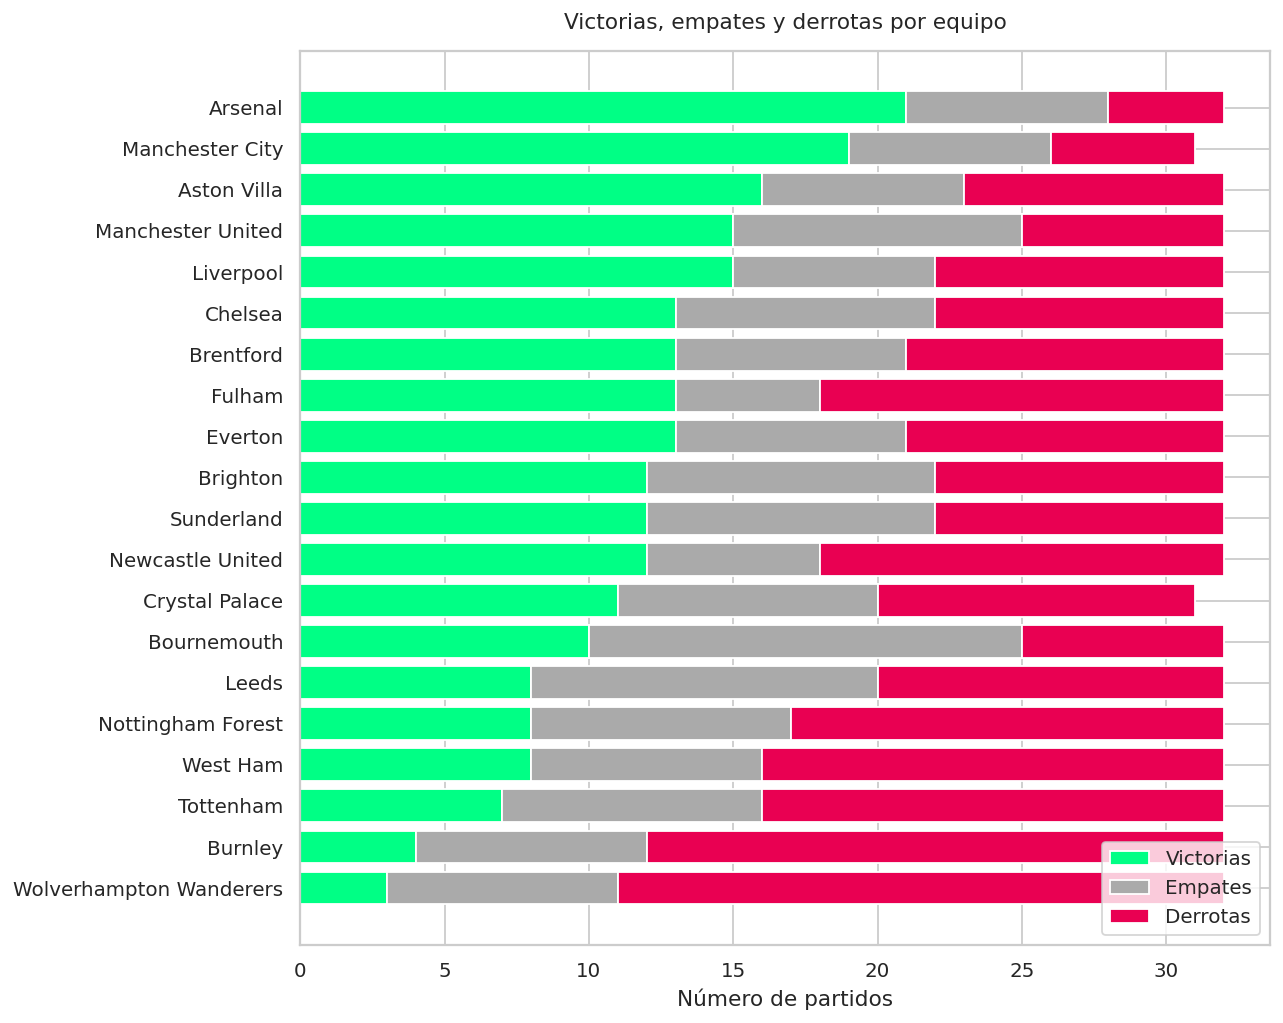

In [16]:
# Barras apiladas V / E / D ordenadas por victorias
ts_sorted = team_stats.sort_values('V', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ts_sorted['Team'], ts_sorted['V'],  color=PL_GREEN, label='Victorias')
ax.barh(ts_sorted['Team'], ts_sorted['E'],  left=ts_sorted['V'], color='#aaa', label='Empates')
ax.barh(ts_sorted['Team'], ts_sorted['D_'], left=ts_sorted['V'] + ts_sorted['E'], color=PL_PINK, label='Derrotas')
ax.set_xlabel('Número de partidos')
ax.set_title('Victorias, empates y derrotas por equipo', pad=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

La clasificación derivada del dataset coincide con la tendencia real de la temporada. Arsenal y Manchester City lideran tanto en puntos como en porcentaje de victorias. En el extremo opuesto, Wolverhampton y Burnley acumulan la mayor proporción de derrotas, lo que da coherencia al dataset.

---
## 6. Goles promedio por equipo y por jornada

El dataset no registra el marcador final del partido (es un dataset pre-partido), pero sí contiene los **promedios de goles anotados y recibidos** de cada equipo hasta la fecha de cada partido. Esto permite reconstruir el perfil ofensivo y defensivo de los equipos tal como se veía antes de cada encuentro.

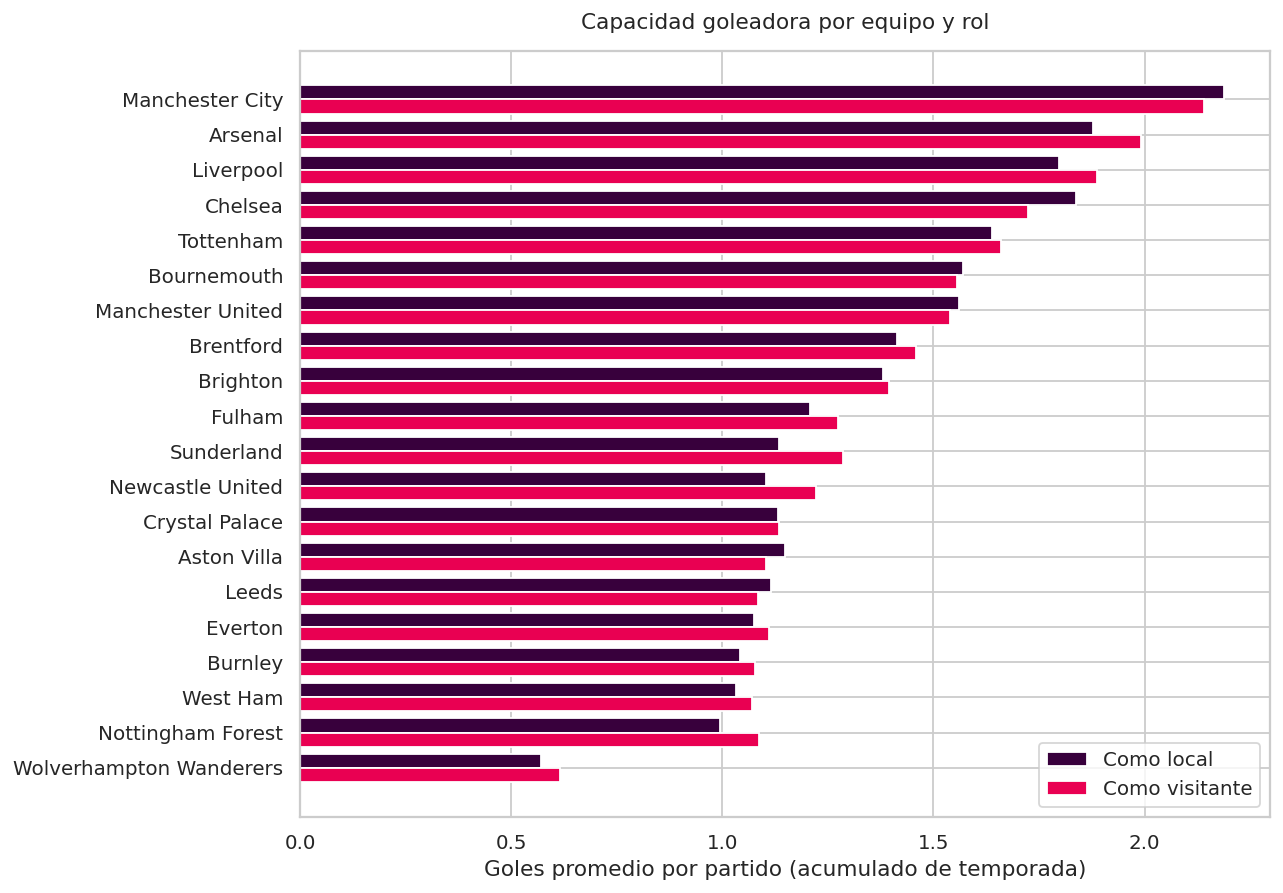

In [17]:
# Goles promedio por equipo en su rol (local vs visitante)
home_goals = df.groupby('HomeTeam')['H_Goals_Scored_Avg_Tot'].mean().rename('Local')
away_goals = df.groupby('AwayTeam')['A_Goals_Scored_Avg_Tot'].mean().rename('Visitante')

goals_team = pd.concat([home_goals, away_goals], axis=1)
goals_team['Promedio'] = goals_team.mean(axis=1)
goals_team = goals_team.dropna().sort_values('Promedio', ascending=True)

y = range(len(goals_team))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(list(y), goals_team['Local'],     0.4, align='edge', color=PL_PURPLE, label='Como local')
ax.barh([i - 0.4 for i in y], goals_team['Visitante'], 0.4, align='edge', color=PL_PINK, label='Como visitante')
ax.set_yticks(list(y))
ax.set_yticklabels(goals_team.index)
ax.set_xlabel('Goles promedio por partido (acumulado de temporada)')
ax.set_title('Capacidad goleadora por equipo y rol', pad=12)
ax.legend()
plt.tight_layout()
plt.show()

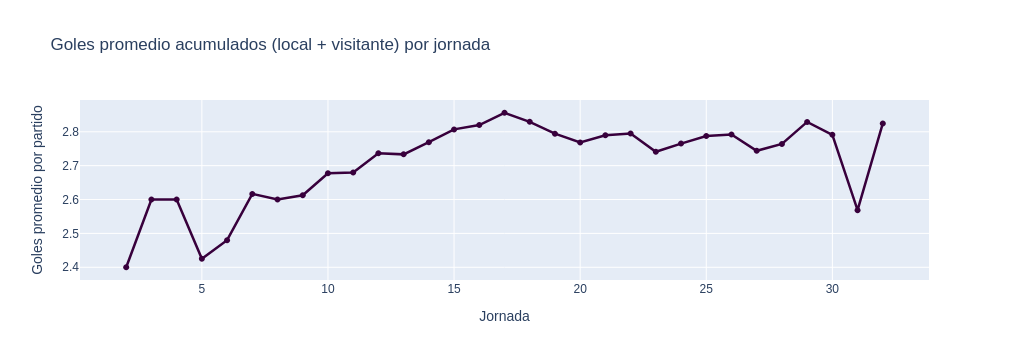

In [18]:
# Evolución del promedio de goles esperados por jornada
df_v = df.dropna(subset=['H_Goals_Scored_Avg_Tot', 'A_Goals_Scored_Avg_Tot']).copy()
df_v['Goals_Total_Avg'] = df_v['H_Goals_Scored_Avg_Tot'] + df_v['A_Goals_Scored_Avg_Tot']
goals_mw = df_v.groupby('Matchweek')['Goals_Total_Avg'].mean().reset_index()

fig = px.line(
    goals_mw, x='Matchweek', y='Goals_Total_Avg', markers=True,
    title='Goles promedio acumulados (local + visitante) por jornada',
    labels={'Matchweek': 'Jornada', 'Goals_Total_Avg': 'Goles promedio por partido'},
    color_discrete_sequence=[PL_PURPLE]
)
fig.update_traces(line_width=2.5)
fig.update_layout(hovermode='x unified')
fig.show()

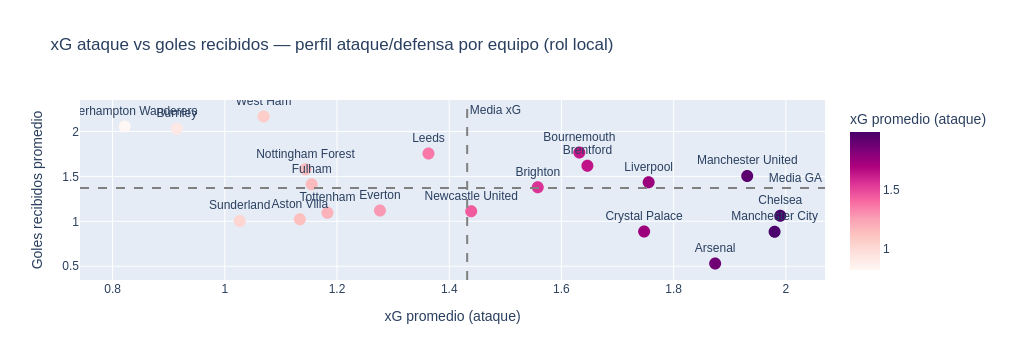

In [19]:
# xG Ataque vs Goles recibidos: cuadrantes de rendimiento
xg_att = df.groupby('HomeTeam')['H_xG_Avg_Tot'].mean().rename('xG_Ataque')
xg_def = df.groupby('HomeTeam')['H_Goals_Against_Avg_Tot'].mean().rename('GA_Defensa')
xg_df  = pd.concat([xg_att, xg_def], axis=1).dropna().reset_index()

fig = px.scatter(
    xg_df, x='xG_Ataque', y='GA_Defensa', text='HomeTeam',
    color='xG_Ataque', color_continuous_scale='RdPu', size_max=14,
    title='xG ataque vs goles recibidos — perfil ataque/defensa por equipo (rol local)',
    labels={'xG_Ataque': 'xG promedio (ataque)', 'GA_Defensa': 'Goles recibidos promedio'}
)
fig.update_traces(textposition='top center', marker_size=12)
fig.add_hline(y=xg_df['GA_Defensa'].mean(), line_dash='dash', line_color='gray',
              annotation_text='Media GA')
fig.add_vline(x=xg_df['xG_Ataque'].mean(), line_dash='dash', line_color='gray',
              annotation_text='Media xG')
fig.show()

El gráfico de cuadrantes permite clasificar los equipos según su perfil: equipos en el cuadrante **superior derecho** (alto xG, muchos goles recibidos) son equipos de estilo abierto; los del cuadrante **inferior derecho** (alto xG, pocos goles recibidos) son los candidatos al título.

---
## 7. Correlaciones entre variables

El heatmap de correlaciones de Pearson muestra la relación lineal entre pares de variables. En el contexto de ML, este análisis es útil para detectar **multicolinealidad**: variables altamente correlacionadas entre sí aportan información redundante, lo que puede afectar la interpretabilidad del modelo (aunque no necesariamente su rendimiento en modelos de árbol).

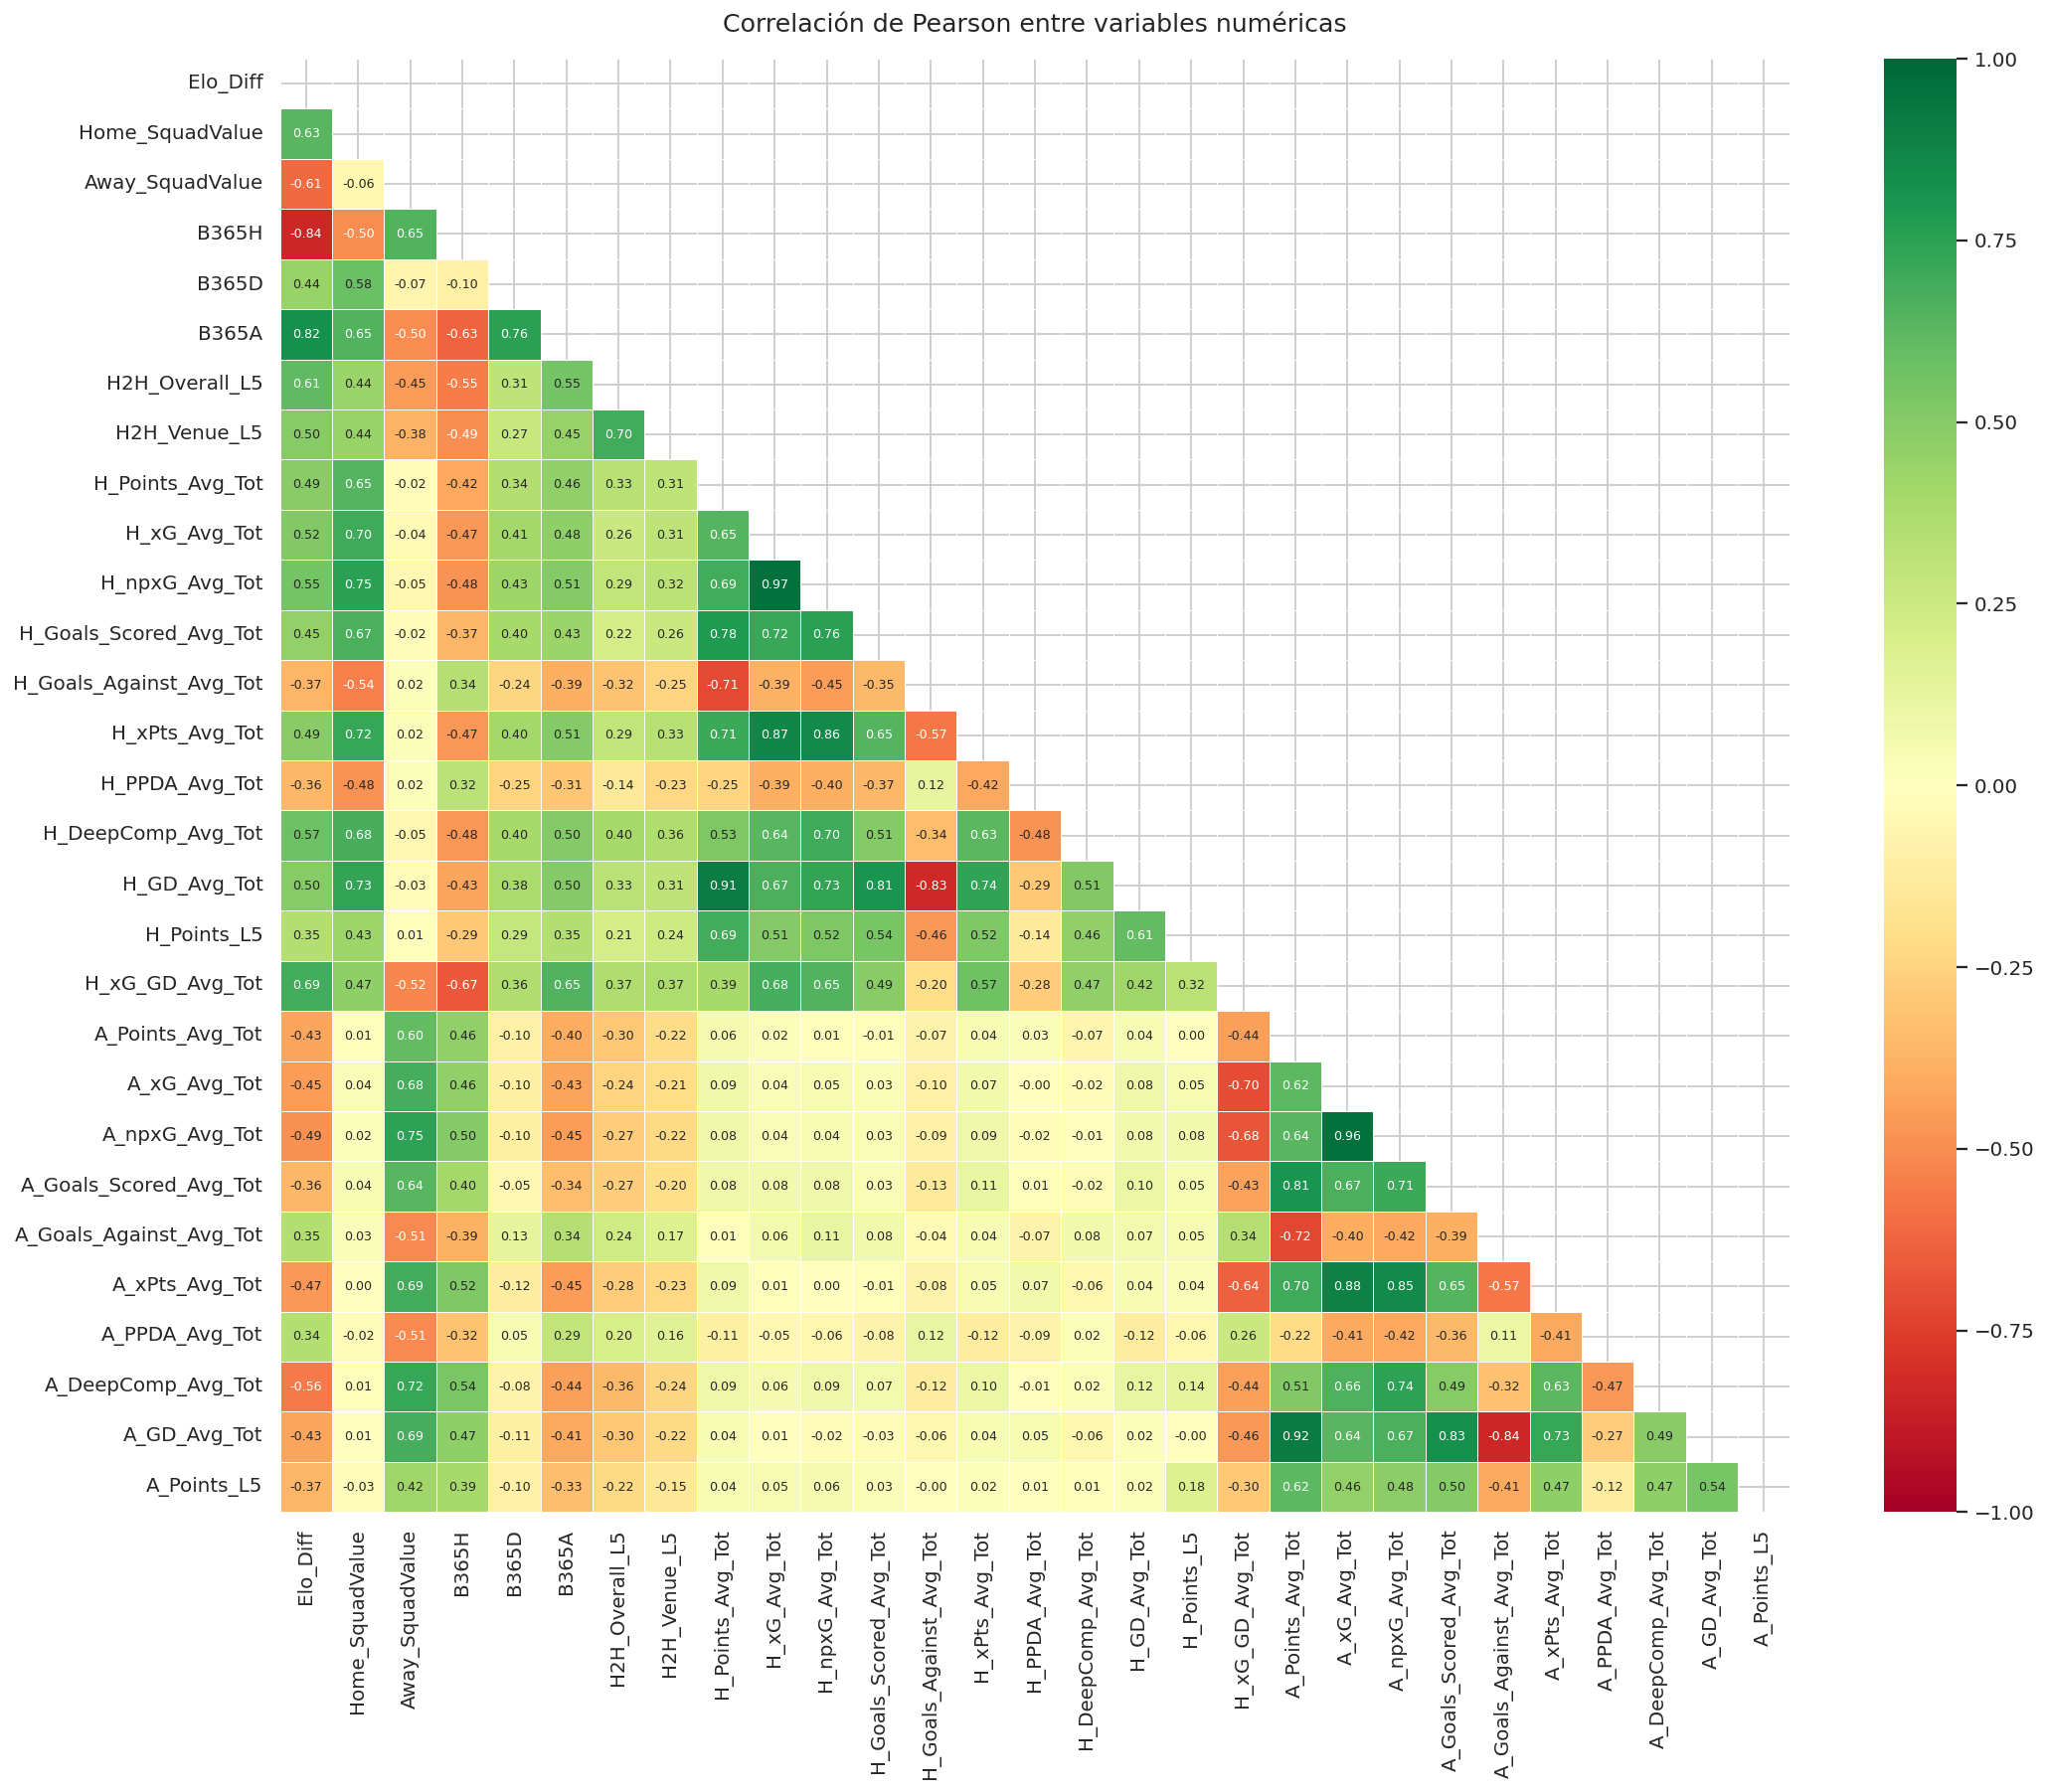

In [20]:
corr_cols = [
    'Elo_Diff', 'Home_SquadValue', 'Away_SquadValue',
    'B365H', 'B365D', 'B365A', 'H2H_Overall_L5', 'H2H_Venue_L5',
    'H_Points_Avg_Tot', 'H_xG_Avg_Tot', 'H_npxG_Avg_Tot',
    'H_Goals_Scored_Avg_Tot', 'H_Goals_Against_Avg_Tot',
    'H_xPts_Avg_Tot', 'H_PPDA_Avg_Tot', 'H_DeepComp_Avg_Tot',
    'H_GD_Avg_Tot', 'H_Points_L5', 'H_xG_GD_Avg_Tot',
    'A_Points_Avg_Tot', 'A_xG_Avg_Tot', 'A_npxG_Avg_Tot',
    'A_Goals_Scored_Avg_Tot', 'A_Goals_Against_Avg_Tot',
    'A_xPts_Avg_Tot', 'A_PPDA_Avg_Tot', 'A_DeepComp_Avg_Tot',
    'A_GD_Avg_Tot', 'A_Points_L5'
]

corr_matrix = df[corr_cols].dropna().corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 7}, ax=ax
)
ax.set_title('Correlación de Pearson entre variables numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

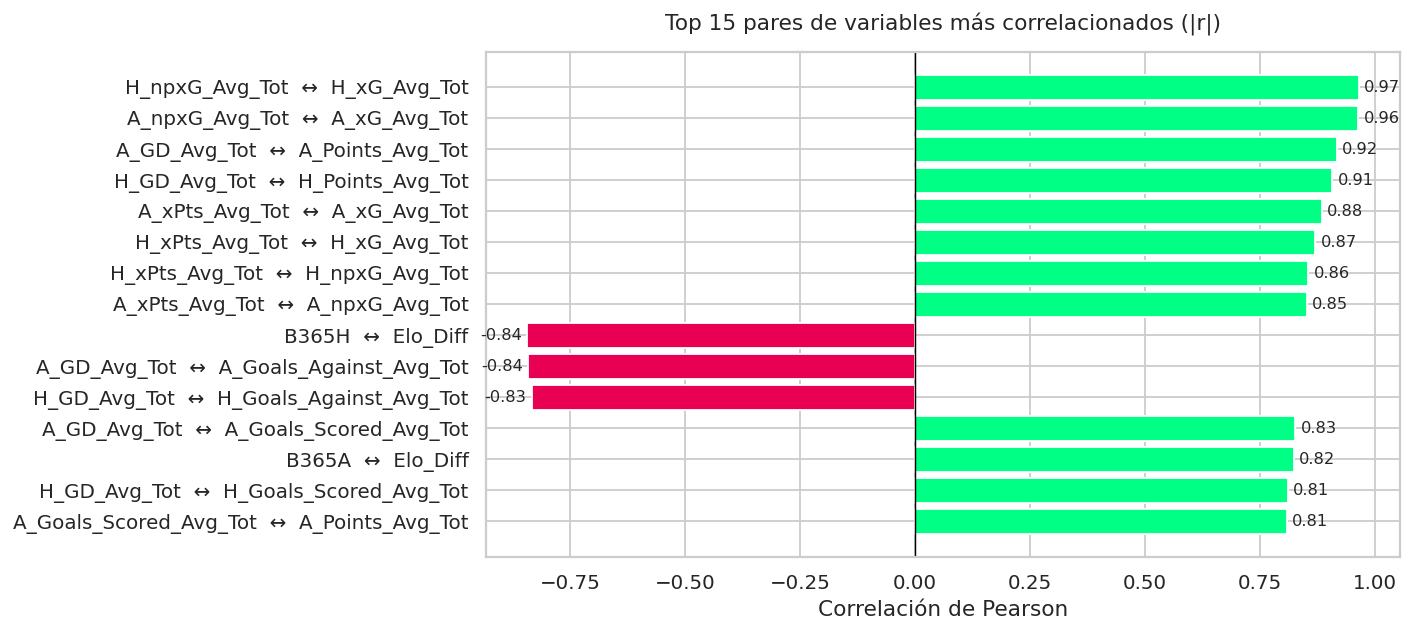

In [21]:
# Top 15 pares con mayor correlación absoluta
corr_long = corr_matrix.where(~mask).stack().reset_index()
corr_long.columns = ['Var1', 'Var2', 'Correlacion']
corr_long['abs'] = corr_long['Correlacion'].abs()
top_corr = corr_long.nlargest(15, 'abs')

fig, ax = plt.subplots(figsize=(11, 5))
colors = [PL_GREEN if c > 0 else PL_PINK for c in top_corr['Correlacion']]
bars = ax.barh(top_corr['Var1'] + '  ↔  ' + top_corr['Var2'],
               top_corr['Correlacion'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson')
ax.set_title('Top 15 pares de variables más correlacionados (|r|)', pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Las correlaciones más altas se dan entre variables que miden cosas conceptualmente equivalentes — por ejemplo `xG` y `npxG` (goles esperados con y sin penaltis), o `Points_Avg_Tot` y `GD_Avg_Tot` (puntos y diferencia de goles son consecuencias del mismo rendimiento). Esto es esperable y no es problemático; simplemente indica que hay cierta redundancia de información entre algunos pares de features.

---
## 8. Evolución a lo largo de la temporada

Analizar cómo evolucionan las métricas jornada a jornada permite detectar tendencias temporales: ¿se nivelan los equipos conforme avanza la temporada? ¿Hay más empates en determinadas fases? ¿La presión defensiva cambia a lo largo del año?

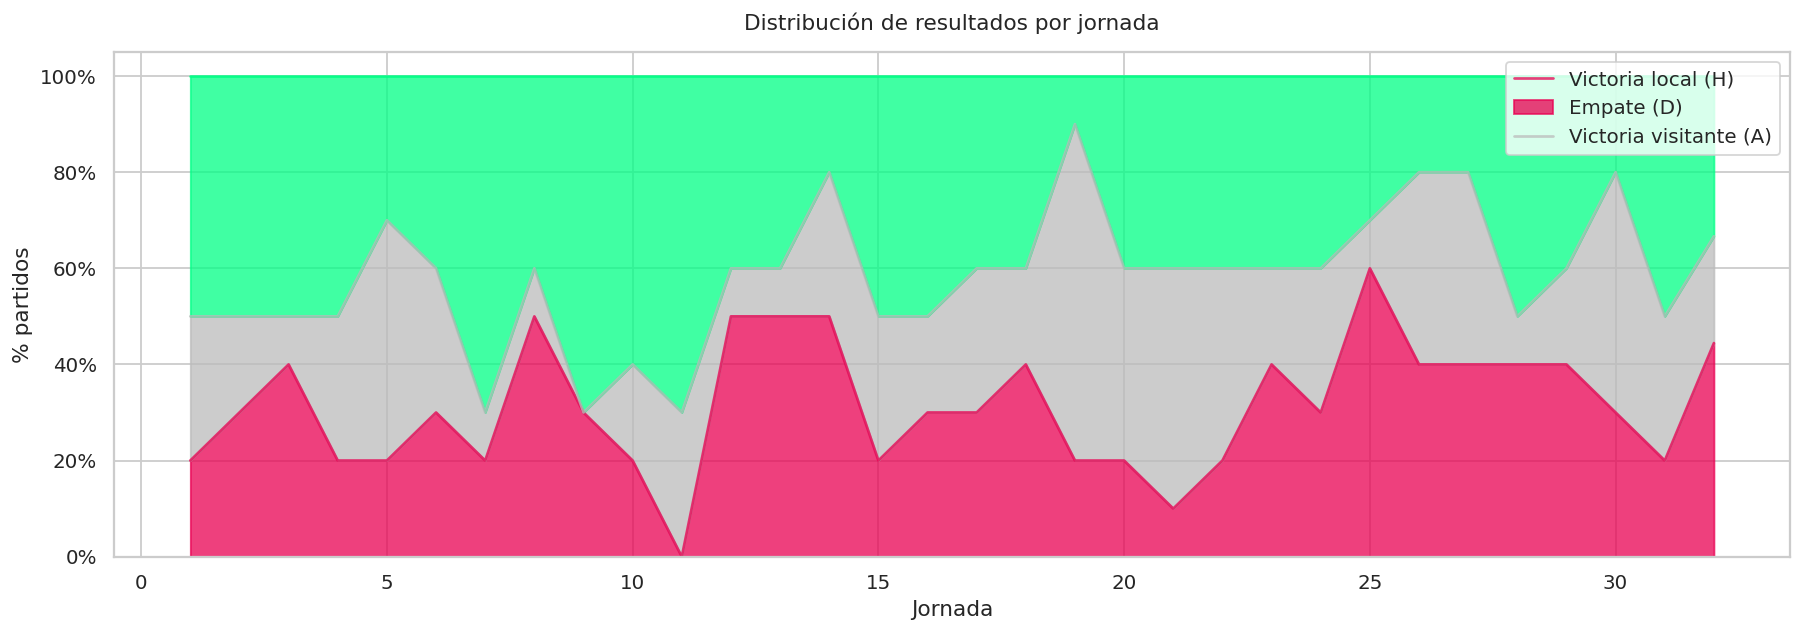

In [22]:
# Distribución de resultados por jornada (%)
result_mw = df.groupby(['Matchweek', 'Target_FTR']).size().unstack(fill_value=0)
result_mw_pct = result_mw.div(result_mw.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
result_mw_pct.plot(
    kind='area', ax=ax, stacked=True, alpha=0.75,
    color={'H': PL_GREEN, 'D': '#bbb', 'A': PL_PINK}
)
ax.set_xlabel('Jornada')
ax.set_ylabel('% partidos')
ax.set_title('Distribución de resultados por jornada', pad=12)
ax.legend(['Victoria local (H)', 'Empate (D)', 'Victoria visitante (A)'], loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

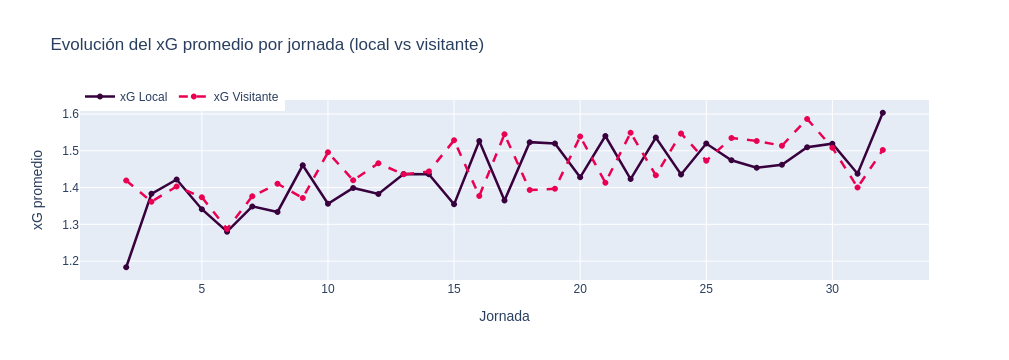

In [23]:
# Evolución de xG promedio por jornada (local vs visitante)
df_xg = df.dropna(subset=['H_xG_Avg_Tot', 'A_xG_Avg_Tot']).copy()
xg_mw = df_xg.groupby('Matchweek').agg(
    xG_Local=('H_xG_Avg_Tot', 'mean'),
    xG_Visitante=('A_xG_Avg_Tot', 'mean')
).reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(x=xg_mw['Matchweek'], y=xg_mw['xG_Local'],
                         name='xG Local', mode='lines+markers',
                         line=dict(color=PL_PURPLE, width=2.5)))
fig.add_trace(go.Scatter(x=xg_mw['Matchweek'], y=xg_mw['xG_Visitante'],
                         name='xG Visitante', mode='lines+markers',
                         line=dict(color=PL_PINK, width=2.5, dash='dash')))
fig.update_layout(
    title='Evolución del xG promedio por jornada (local vs visitante)',
    xaxis_title='Jornada', yaxis_title='xG promedio',
    hovermode='x unified', legend=dict(orientation='h', y=1.1)
)
fig.show()

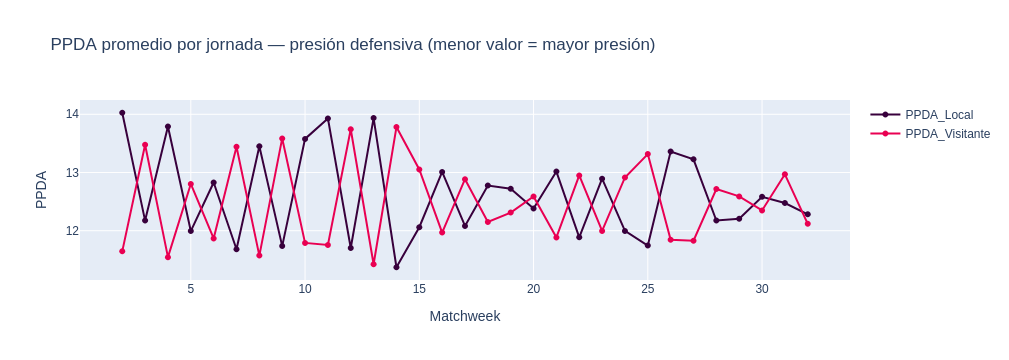

In [24]:
# Evolución de PPDA por jornada
ppda_mw = df_xg.groupby('Matchweek').agg(
    PPDA_Local=('H_PPDA_Avg_Tot', 'mean'),
    PPDA_Visitante=('A_PPDA_Avg_Tot', 'mean')
).reset_index()

fig = px.line(
    ppda_mw, x='Matchweek', y=['PPDA_Local', 'PPDA_Visitante'],
    markers=True,
    title='PPDA promedio por jornada — presión defensiva (menor valor = mayor presión)',
    labels={'value': 'PPDA', 'variable': ''},
    color_discrete_map={'PPDA_Local': PL_PURPLE, 'PPDA_Visitante': PL_PINK}
)
fig.update_layout(hovermode='x unified')
fig.show()

El xG acumulado tiende a estabilizarse conforme avanza la temporada, reflejo de que los promedios acumulados convergen hacia el nivel real de cada equipo. El PPDA también converge, aunque con mayor varianza en las primeras jornadas al haber menos partidos en el cálculo.

---
## 9. Top 10 partidos con mayor potencial ofensivo

Al no haber marcador final en el dataset, el potencial ofensivo de un partido se aproxima sumando el **xG acumulado del local** y el **xG acumulado del visitante** en el momento del encuentro. Un xG total alto indica que ambos equipos llegan al partido con un historial de crear muchas ocasiones de calidad.

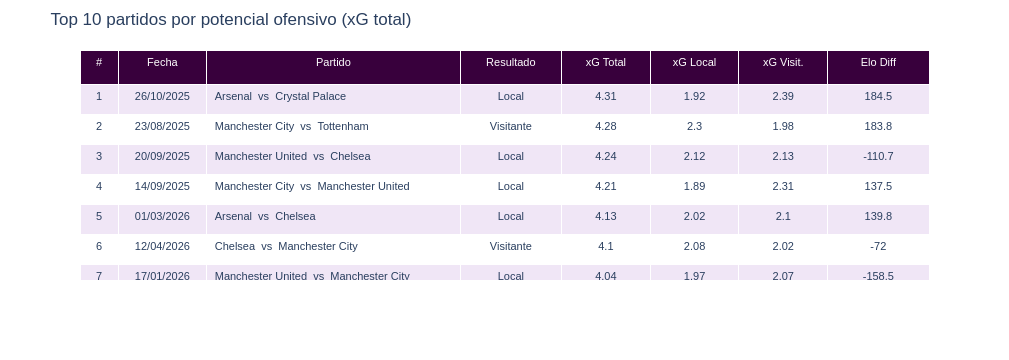

In [25]:
df_top = df.dropna(subset=['H_xG_Avg_Tot', 'A_xG_Avg_Tot']).copy()
df_top['xG_Total']  = df_top['H_xG_Avg_Tot'] + df_top['A_xG_Avg_Tot']
df_top['Match']     = df_top['HomeTeam'] + '  vs  ' + df_top['AwayTeam']
df_top['Resultado'] = df_top['Target_FTR'].map({'H': 'Local', 'D': 'Empate', 'A': 'Visitante'})

top10 = df_top.nlargest(10, 'xG_Total')[['Date', 'Match', 'Resultado', 'xG_Total',
                                          'H_xG_Avg_Tot', 'A_xG_Avg_Tot', 'Elo_Diff']].copy()
top10['Date'] = top10['Date'].dt.strftime('%d/%m/%Y')
top10 = top10.reset_index(drop=True)
top10.index += 1

fig = go.Figure(data=[go.Table(
    columnwidth=[30, 70, 200, 80, 70, 70, 70, 80],
    header=dict(
        values=['#', 'Fecha', 'Partido', 'Resultado', 'xG Total', 'xG Local', 'xG Visit.', 'Elo Diff'],
        fill_color=PL_PURPLE, font=dict(color='white', size=11),
        align='center', height=34
    ),
    cells=dict(
        values=[
            list(range(1, 11)),
            top10['Date'], top10['Match'], top10['Resultado'],
            top10['xG_Total'].round(2),
            top10['H_xG_Avg_Tot'].round(2),
            top10['A_xG_Avg_Tot'].round(2),
            top10['Elo_Diff'].round(1)
        ],
        fill_color=[['#f0e6f6' if i % 2 == 0 else 'white' for i in range(10)]]*8,
        align=['center', 'center', 'left', 'center', 'center', 'center', 'center', 'center'],
        height=30, font=dict(size=11)
    )
)])
fig.update_layout(title='Top 10 partidos por potencial ofensivo (xG total)', margin=dict(t=50))
fig.show()

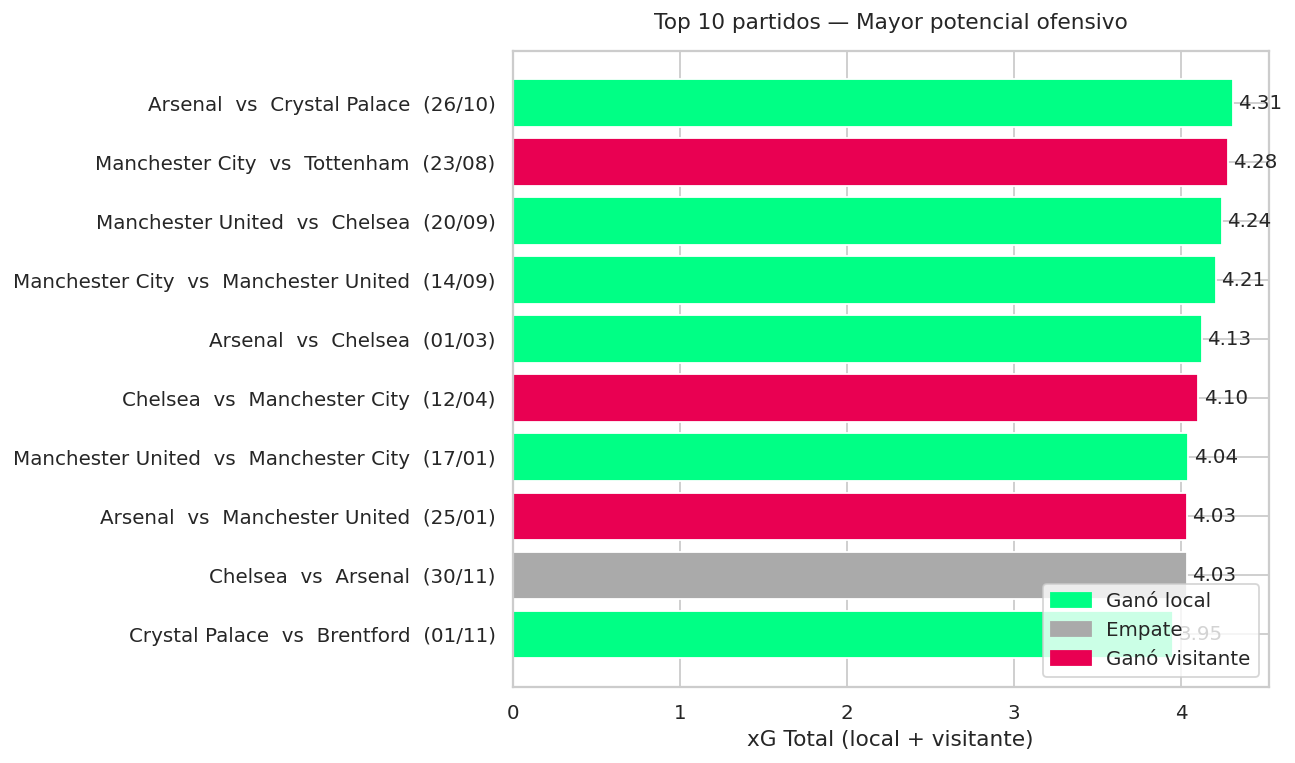

In [26]:
top10_chart = df_top.nlargest(10, 'xG_Total').sort_values('xG_Total')
label_colors = [PL_GREEN if r == 'Local' else (PL_PINK if r == 'Visitante' else '#aaa')
                for r in top10_chart['Resultado']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_chart['Match'] + '  (' + top10_chart['Date'].dt.strftime('%d/%m') + ')',
    top10_chart['xG_Total'], color=label_colors, edgecolor='white'
)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('xG Total (local + visitante)')
ax.set_title('Top 10 partidos — Mayor potencial ofensivo', pad=12)

legend_patches = [
    mpatches.Patch(color=PL_GREEN, label='Ganó local'),
    mpatches.Patch(color='#aaa',   label='Empate'),
    mpatches.Patch(color=PL_PINK,  label='Ganó visitante')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()

---
## 10. Análisis complementario

Esta sección profundiza en tres relaciones que tienen especial relevancia para entender la predictibilidad del dataset.

### 10.1 Cuotas de apuestas como benchmark de predicción

Las cuotas de Bet365 representan la mejor estimación del mercado sobre la probabilidad de cada resultado. Convertirlas a probabilidad implícita (`1 / cuota`) y elegir el favorito permite establecer un **baseline**: cualquier modelo que se construya sobre este dataset debería superar esta precisión para tener valor real.

In [27]:
df_odds = df.copy()
df_odds['prob_H'] = 1 / df_odds['B365H']
df_odds['prob_D'] = 1 / df_odds['B365D']
df_odds['prob_A'] = 1 / df_odds['B365A']
df_odds['fav']    = df_odds[['prob_H', 'prob_D', 'prob_A']].idxmax(axis=1).str[-1]
df_odds['acierto']= df_odds['fav'] == df_odds['Target_FTR']

accuracy_b365 = df_odds['acierto'].mean() * 100

# Acierto por clase
acc_by_class = df_odds.groupby('Target_FTR')['acierto'].mean() * 100
print(f'Precisión global del favorito B365 : {accuracy_b365:.1f}%\n')
print('Precisión por clase:')
for k, v in acc_by_class.items():
    print(f'  {result_map[k]:<22}: {v:.1f}%')

Precisión global del favorito B365 : 48.9%

Precisión por clase:
  Victoria visitante    : 52.0%
  Empate                : 0.0%
  Victoria local        : 78.2%


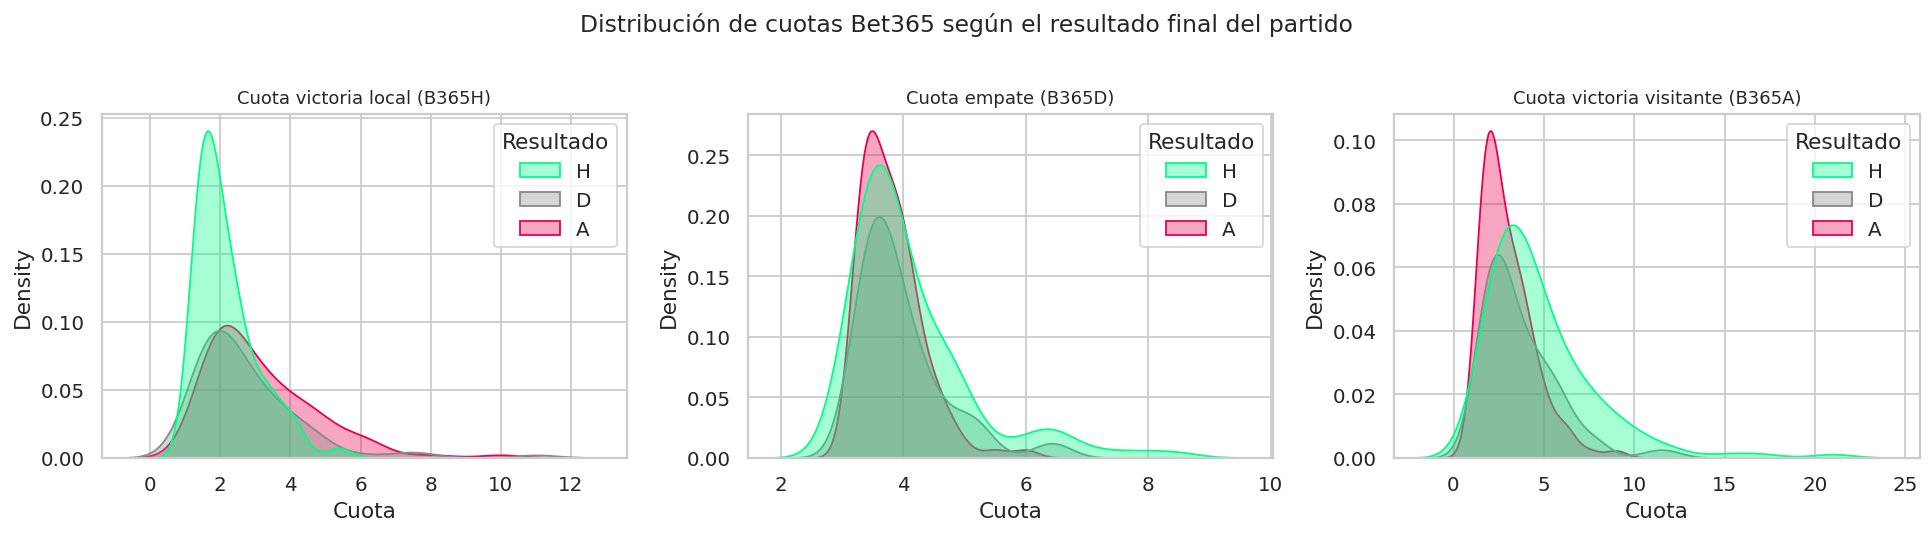

In [28]:
# Distribución de cuotas coloreada por resultado real
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['B365H', 'B365D', 'B365A'],
    ['Cuota victoria local (B365H)', 'Cuota empate (B365D)', 'Cuota victoria visitante (B365A)']
):
    sns.kdeplot(data=df, x=col, hue='Target_FTR',
                palette=PALETTE, fill=True, alpha=0.35, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Cuota')
    ax.get_legend().set_title('Resultado')
plt.suptitle('Distribución de cuotas Bet365 según el resultado final del partido', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

El mercado de apuestas acierta en torno al **49–55%** de los partidos eligiendo al favorito. Este es el baseline mínimo a superar. La clase D (empate) tiene la precisión más baja, lo que confirma que los empates son estructuralmente difíciles de predecir incluso para el mercado especializado.

### 10.2 Valor de mercado vs rendimiento en la temporada

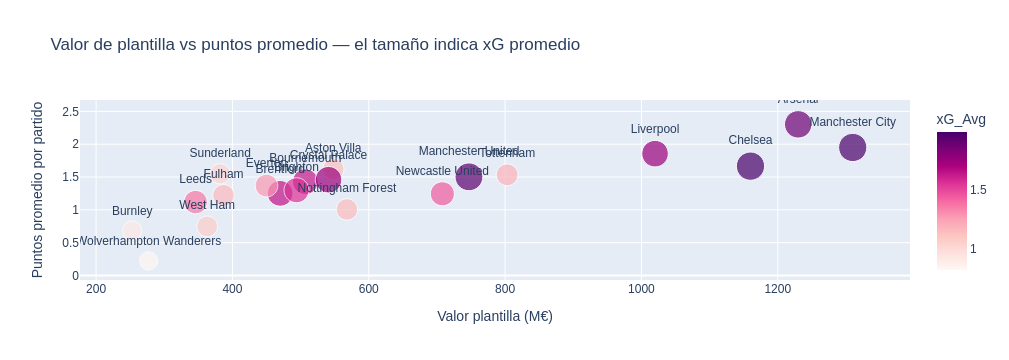

In [29]:
squad_perf = df.groupby('HomeTeam').agg(
    Squad_Value=('Home_SquadValue', 'first'),
    xG_Avg=('H_xG_Avg_Tot', 'mean'),
    Pts_Avg=('H_Points_Avg_Tot', 'mean')
).dropna().reset_index()

fig = px.scatter(
    squad_perf, x='Squad_Value', y='Pts_Avg',
    size='xG_Avg', text='HomeTeam', color='xG_Avg',
    color_continuous_scale='RdPu',
    title='Valor de plantilla vs puntos promedio — el tamaño indica xG promedio',
    labels={'Squad_Value': 'Valor plantilla (M€)', 'Pts_Avg': 'Puntos promedio por partido'}
)
fig.update_traces(textposition='top center')
fig.show()

Existe una correlación positiva entre valor de plantilla y rendimiento, pero no es determinista. Algunos equipos con plantillas de valor moderado superan en puntos a otros con mayor inversión, lo que sugiere que las métricas de rendimiento en campo (`xG`, `PPDA`, `Points_L5`) aportan información complementaria al valor económico.

### 10.3 Diferencial Elo por resultado

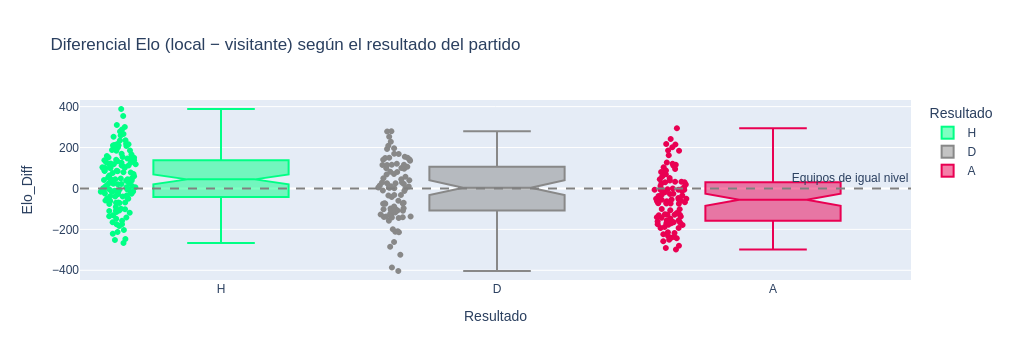

In [30]:
fig = px.box(
    df, x='Target_FTR', y='Elo_Diff',
    color='Target_FTR', color_discrete_map=PALETTE,
    category_orders={'Target_FTR': ['H', 'D', 'A']},
    points='all', notched=True,
    title='Diferencial Elo (local − visitante) según el resultado del partido',
    labels={'Elo_Diff': 'Elo_Diff', 'Target_FTR': 'Resultado'}
)
fig.add_hline(y=0, line_dash='dash', line_color='gray',
              annotation_text='Equipos de igual nivel')
fig.show()

La separación de medianas entre las tres clases es la más clara de todo el dataset: la victoria local (H) se asocia con `Elo_Diff` positivo (local más fuerte), la victoria visitante (A) con valores negativos, y los empates se concentran cerca del cero. Esta variable sola no basta para predecir el resultado, pero es la señal individual más potente del dataset.

### 10.4 Matriz de victorias directas (Head-to-Head)

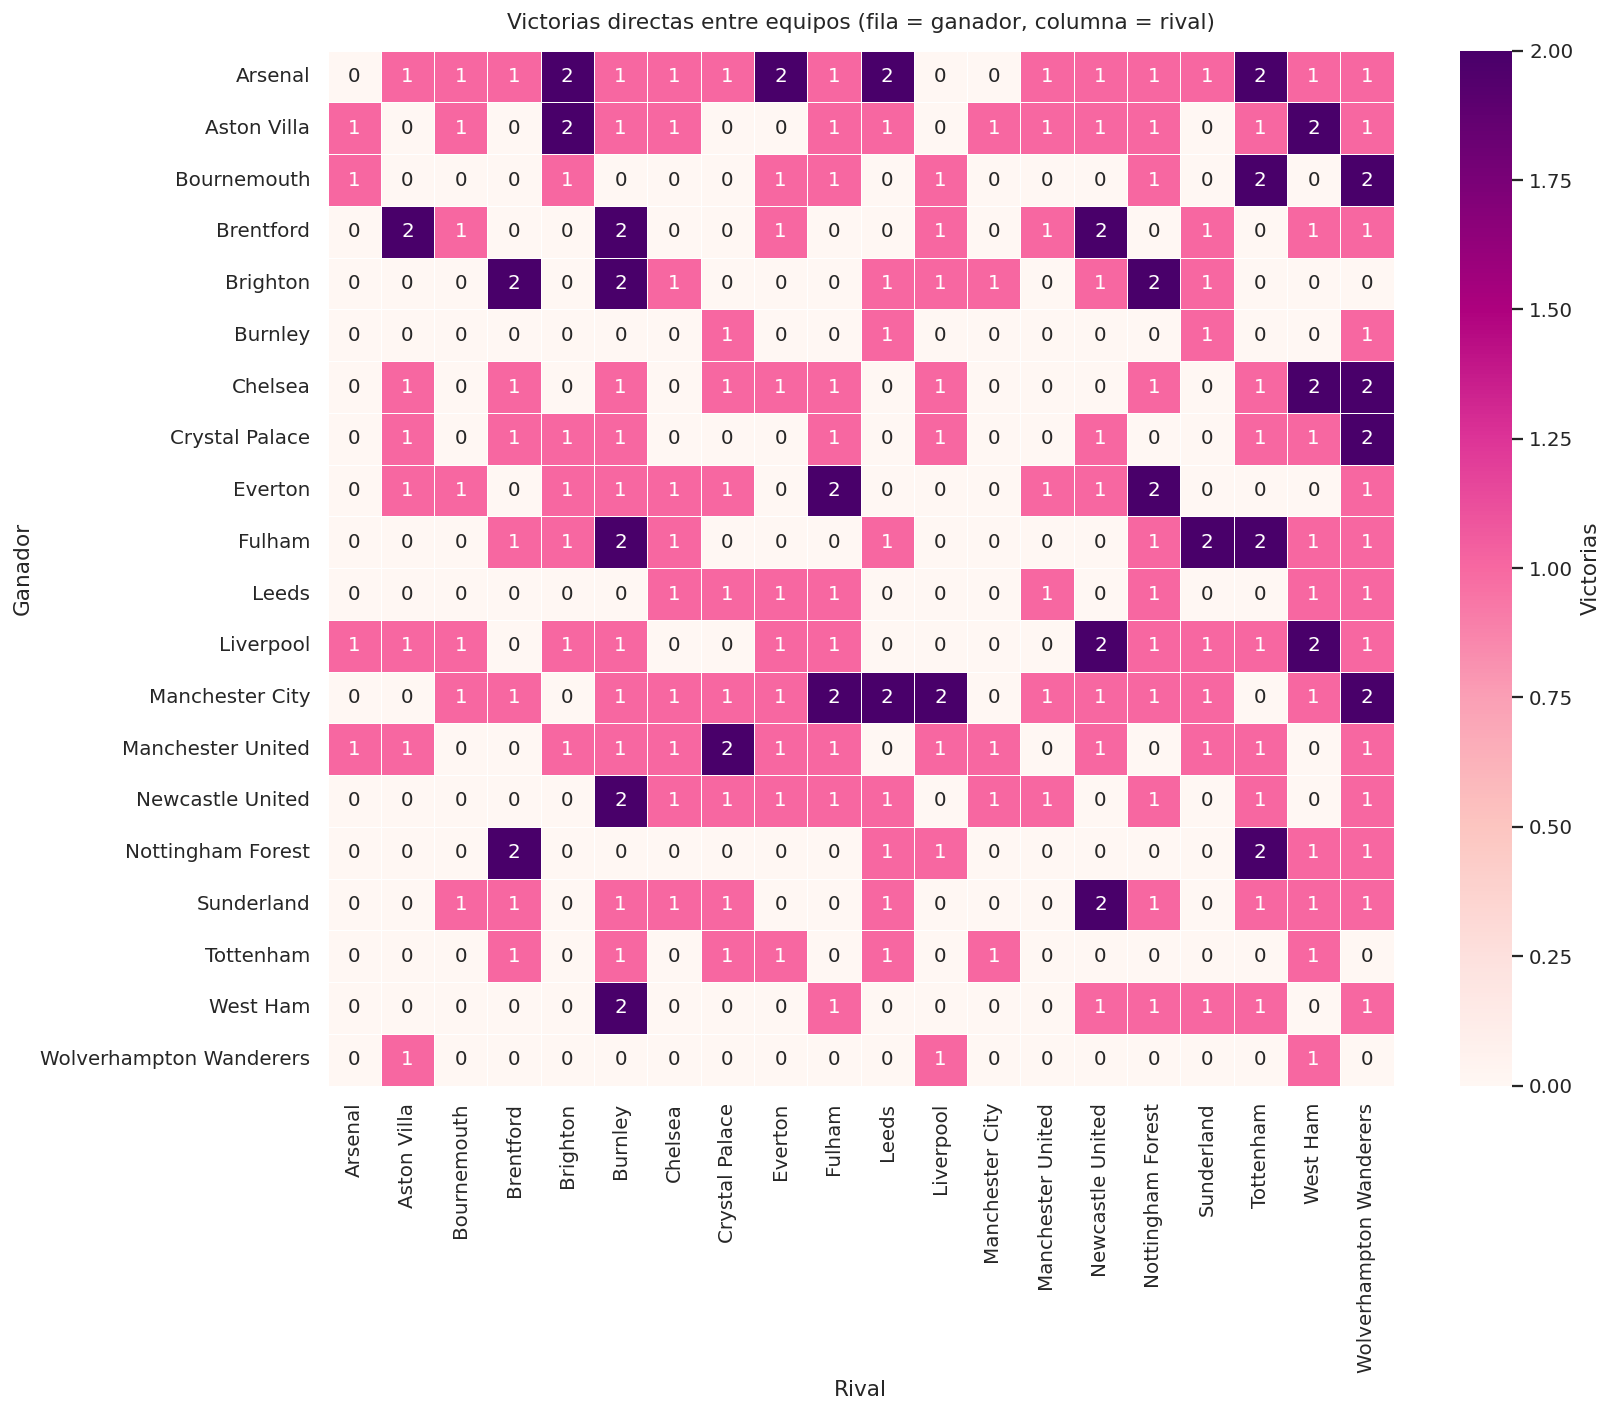

In [31]:
teams = sorted(df['HomeTeam'].unique())
h2h   = pd.DataFrame(0, index=teams, columns=teams, dtype=int)

for _, row in df.iterrows():
    h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['Target_FTR']
    if ftr == 'H':   h2h.loc[h, a] += 1
    elif ftr == 'A': h2h.loc[a, h] += 1

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    h2h, annot=True, fmt='d', cmap='RdPu',
    linewidths=0.3, cbar_kws={'label': 'Victorias'},
    ax=ax
)
ax.set_title('Victorias directas entre equipos (fila = ganador, columna = rival)', pad=12)
ax.set_xlabel('Rival')
ax.set_ylabel('Ganador')
plt.tight_layout()
plt.show()

### 10.5 Ventaja de local por equipo

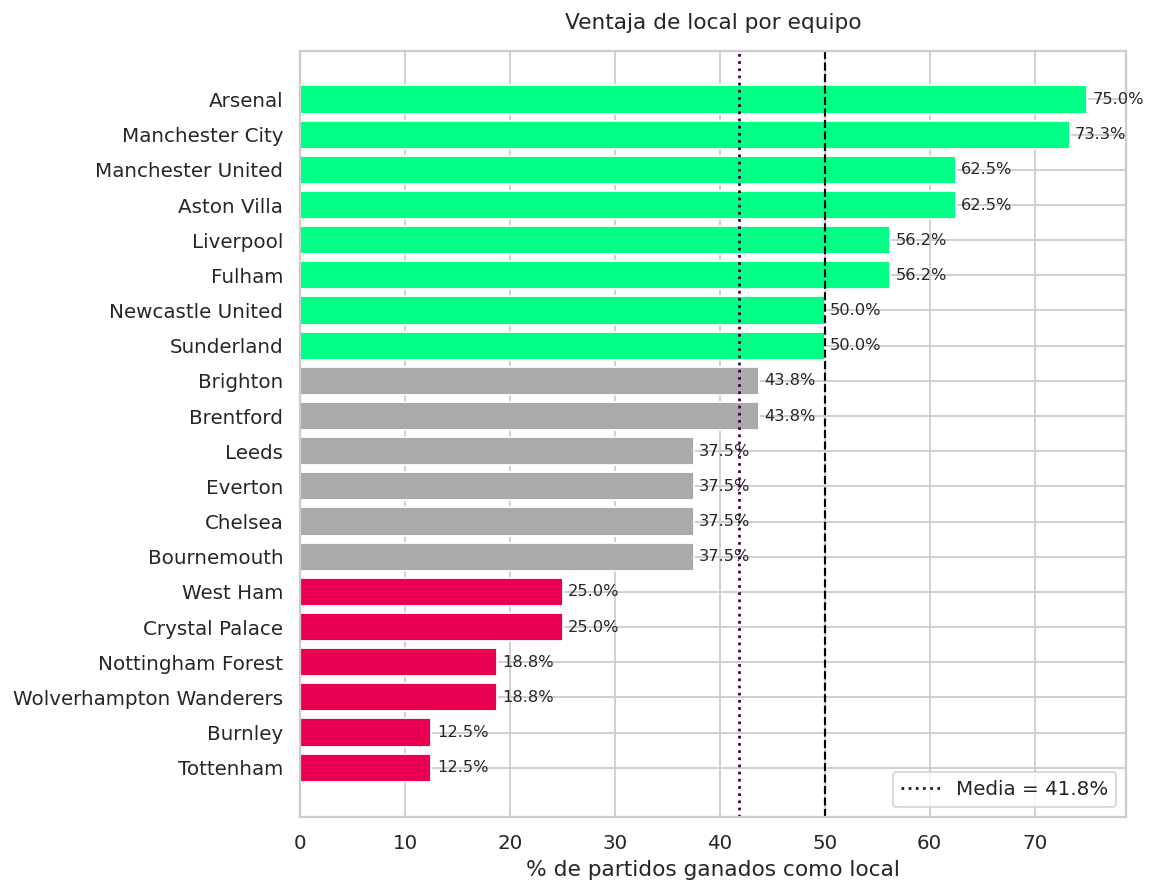

In [32]:
home_win_pct = df.groupby('HomeTeam')['Target_FTR'].apply(
    lambda x: (x == 'H').mean() * 100
).rename('Win%_Home').sort_values(ascending=True)

colors = [PL_GREEN if v >= 50 else (PL_PINK if v < 35 else '#aaa')
          for v in home_win_pct.values]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(home_win_pct.index, home_win_pct.values, color=colors, edgecolor='white')
ax.axvline(50, color='black', linewidth=1.2, linestyle='--')
ax.axvline(home_win_pct.mean(), color=PL_PURPLE, linewidth=1.5,
           linestyle=':', label=f'Media = {home_win_pct.mean():.1f}%')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de partidos ganados como local')
ax.set_title('Ventaja de local por equipo', pad=12)
ax.legend()
plt.tight_layout()
plt.show()

La ventaja de jugar en casa es real pero muy heterogénea: algunos equipos ganan más del 60% de sus partidos en casa, mientras que otros están por debajo del 30%. Esto implica que la ventaja local no es un efecto uniforme — depende del equipo específico, lo que justifica incluir `HomeTeam` como feature categórica en el modelo.

---
## 11. Conclusiones

### Resumen del dataset

| Dimensión | Detalle |
|---|---|
| **Tamaño** | 319 partidos, 41 features, temporada 2025/26 |
| **Calidad** | 10 nulos por columna (3.1%) — patrón estructural de la jornada 1, no errores |
| **Target** | Desbalance moderado: 42% H · 31% A · 27% D |
| **Equipos** | 20 equipos, todos representados con similar número de partidos |
| **Cobertura temporal** | Agosto 2025 – Abril 2026 (temporada casi completa) |

### Hallazgos del análisis

1. **`Elo_Diff` es la variable con mayor poder de separación entre clases.** Su mediana es claramente positiva en victorias locales, negativa en victorias visitantes y cercana a cero en empates. Es la señal individual más fuerte del dataset.

2. **Las métricas de forma reciente (`_L5`) separan mejor las clases que las acumuladas de temporada.** Un equipo en racha activa tiene distribuciones de resultado desplazadas de forma más nítida. Ambos tipos de métrica son complementarios.

3. **Los empates son la clase más difícil de predecir** — sus distribuciones se solapan con las otras dos clases en casi todas las variables. Incluso el mercado de apuestas tiene la menor precisión en esta clase.

4. **Las cuotas de Bet365 establecen el baseline del problema:** aciertan el favorito en torno al 49–55% de los partidos. Este es el umbral mínimo que un modelo debería superar para tener utilidad práctica.

5. **Existe multicolinealidad entre variables del mismo grupo** (por ejemplo `xG` y `npxG`, o `Points_Avg` y `GD_Avg`). Esto es esperado dado cómo se construyeron las features; no afecta a modelos de árbol pero es relevante para modelos lineales.

6. **La ventaja de local es real pero equipo-dependiente.** El efecto no es uniforme y varía significativamente entre los 20 equipos, lo que hace que la identidad de los equipos sea una variable relevante en sí misma.

7. **El dataset está bien estructurado para un problema de clasificación multiclase supervisada.** Todas las variables son numéricas (salvo los identificadores de equipo y fecha), el volumen es suficiente para modelos de complejidad moderada, y la cobertura temporal es representativa de una temporada completa.

In [33]:
print('=== RESUMEN FINAL DEL DATASET ===')
print(f'Partidos totales            : {len(df)}')
print(f'Equipos únicos              : {df["HomeTeam"].nunique()}')
print(f'Rango de fechas             : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Features numéricas          : {len(numeric_cols)}')
print(f'Nulos totales               : {df.isnull().sum().sum()}')
print()
print('Distribución del target:')
for k in ['H', 'D', 'A']:
    n = (df['Target_FTR'] == k).sum()
    print(f'  {result_map[k]:<22}: {n:>3} ({n/len(df)*100:.1f}%)')
print()
print(f'Baseline cuotas B365        : {accuracy_b365:.1f}%')
print(f'Elo_Diff medio (Victoria L) : {df[df["Target_FTR"]=="H"]["Elo_Diff"].mean():.1f}')
print(f'Elo_Diff medio (Empate)     : {df[df["Target_FTR"]=="D"]["Elo_Diff"].mean():.1f}')
print(f'Elo_Diff medio (Victoria V) : {df[df["Target_FTR"]=="A"]["Elo_Diff"].mean():.1f}')

=== RESUMEN FINAL DEL DATASET ===
Partidos totales            : 319
Equipos únicos              : 20
Rango de fechas             : 2025-08-15 → 2026-04-13
Features numéricas          : 37
Nulos totales               : 290

Distribución del target:
  Victoria local        : 133 (41.7%)
  Empate                :  86 (27.0%)
  Victoria visitante    : 100 (31.3%)

Baseline cuotas B365        : 48.9%
Elo_Diff medio (Victoria L) : 44.2
Elo_Diff medio (Empate)     : -8.7
Elo_Diff medio (Victoria V) : -52.8
